[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RISE-MICCAI/rise-tutorials-website/blob/main/rise_tutorials/tuto/BraTS19_Segmentation_Tutorial.ipynb)
[![Open in Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/RISE-MICCAI/rise-tutorials-website/HEAD?labpath=rise_tutorials%2Ftuto%2FBraTS19_Segmentation_Tutorial.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/RISE-MICCAI/rise-tutorials-website/blob/main/rise_tutorials/tuto/BraTS19_Segmentation_Tutorial.ipynb)

# **Brain Tumor Segmentation with U-Net Using the BraTS Dataset: A Beginner’s Tutorial**

**Author**: Yasar Mehmood
**Affiliation**: Information Technology University of the Punjab, Lahore, Punjab, Pakistan.
**Contact**:  yasar.mehmood111@gmail.com

# 1️⃣ Overview
















## Clinical Problem & Motivation
Brain tumors, particularly gliomas, are notoriously difficult to analyze because they vary significantly in shape, size, and texture. Traditionally, a radiologist must manually "trace" the tumor's boundaries slice-by-slice across a 3D scan. This process is:


*   Labor-Intensive: A single patient scan can contain hundreds of individual image slices, making manual tracing extremely slow.
*   Subjective: Because tumor edges are often "fuzzy," two different experts may disagree on where the tumor ends and healthy tissue begins (inter-observer variability).


This tutorial shows how we can use AI to automate this task. By generating a precise 3D map of the tumor (a process called volumetric segmentation), we can provide doctors with consistent, objective measurements. This is vital for calculating exact tumor volumes, planning safer surgeries, and accurately monitoring how a patient responds to treatment over time.

## Tutorial Goals & Learning Path
This session is a step-by-step guide to a complete medical AI pipeline. Together, we will:


*   Explore the BraTS dataset to see how multi-modal MRI sequences (T1, T1c, T2, and FLAIR) highlight specific tumor sub-regions.

*   Prepare medical data by converting raw medical files (.nii) into a format that a deep learning model can understand (tensors).
*   Build the U-Net architecture, which is the most famous and widely used model for medical image segmentation.


*   Compare 2D vs. 3D models to see which one is faster and which one is more accurate.


*   Measure our success using the Dice Score, a standard metric that tells us how well our AI's prediction overlaps with the doctor’s actual "ground truth."

## Target Audience
This tutorial is designed for beginners who are excited about Medical AI. It is perfect for:


*   Students or researchers new to medical image segmentation (even if they have experience in medical image classification).

*   Data scientists looking to transition from natural images (2D) to volumetric medical data (3D).
*   Healthcare professionals who want to understand the "engine" behind AI diagnostic tools.

## Pre-requisites: Are you ready?
To get the most out of this tutorial, we assume you have a "starter kit" of foundational knowledge. If you are missing a piece, don't worry—most of these can be brushed up on quickly!

#### 💻 Technical Skills:


*   Machine Learning Workflow: Familiarity with the standard pipeline: data splitting (Train/Val/Test), backpropagation, and common evaluation metrics.

*   Python & PyTorch: Comfortable with Python syntax and PyTorch basics (e.g., creating Tensors, understanding the Dataset class, and the forward() pass).
*   Image Representation: Understanding how images are stored as numerical arrays (e.g., a 2D grid of intensity values).


*   CNNs (Convolutional Neural Networks): A basic understanding of how a standard CNN works for image classification, including layers like Convolutions and Max-Pooling.


*   The Segmentation Task: Understanding that we are performing pixel-wise (or voxel-wise) classification, where the goal is to assign a label (e.g., 0=Healthy, 1=Tumor) to every single point in the image.
*   Computing Environment: Comfortable using Google Colab and enabling GPU Runtimes to handle the memory-intensive nature of 3D volumetric data.


#### 🧠 Domain Knowledge


*   Basics of MRI: You don't need to be a physicist, but you should know that an MRI scan provides a 3D view of the inside of the body. Instead of one flat photo, it gives us a "volume" made of many slices.

*   MRI Sequences: A basic understanding that different types of MRI scans (like T1 or FLAIR) make different tissues appear brighter or darker.
*   Brain & Tumor Tissue: A basic understanding that a tumor is an abnormal growth within the brain that we need to isolate from healthy tissue.


#### 🛠️ Resource Requirements: Cloud & Storage


*   Google Colab (Free Tier): This tutorial is designed to be accessible without a paid subscription. We will use the standard environment and the **free-tier GPU Runtimes (T4)**.

*   Google Drive Storage (Crucial): We recommend having ~50 GB of free space on your Google Drive to store the extracted/unzipped BraTS dataset and your trained model checkpoints.

# 2️⃣ Introduction



## What is Brain Tumor Segmentation?
In medical imaging, segmentation is the process of precisely delineating the boundaries of a target—in our case, a brain tumor—within a 3D MRI scan. While a classification model might simply tell us "this scan contains a tumor," a segmentation model identifies the exact location and shape of the pathology at the voxel level.

For the BraTS challenge, we go beyond identifying a single "blob." We look for three distinct sub-regions that are clinically significant:


*   Label 1: Necrotic and Non-Enhancing Tumor Core (NCR/NET) – This includes the "dead" core of the tumor (necrosis) as well as solid tumor regions that do not show active contrast enhancement.

*   Label 2: Peritumoral Edema (ED) – The swelling or fluid buildup in the healthy brain tissue surrounding the tumor.

*   Label 4: GD-Enhancing Tumor (ET) – The active, rapidly growing part of the lesion that 'lights up' on a contrast-enhanced T1 scan.







## Why It Matters: Diagnosis and Treatment Planning
Why is this "pixel-perfect" accuracy so critical? Manual segmentation is a bottleneck in modern medicine, often taking significant time of neuroradiologists for a single patient. While the applications are vast, by automating this process, we specifically enable key clinical workflows such as:


*   Surgical Navigation: Surgeons use these 3D maps as a "GPS" during operations to maximize tumor removal while sparing the healthy brain tissue.

*   Radiotherapy Precision: Oncologists need exact boundaries to aim radiation beams accurately, ensuring they destroy the tumor without damaging the surrounding healthy brain.
*   Objective Monitoring: AI allows us to calculate the precise volume of a tumor, making it easy to see if a patient is responding to chemotherapy over time.


## Why BraTS 2019?
While the Brain Tumor Segmentation (BraTS) challenge has grown significantly in scale and complexity in recent years, the 2019 dataset remains a highly practical choice for our tutorial. Our selection is based on three realistic factors:


*   Resource-Friendly Scale: Recent versions of the BraTS dataset (2023 and beyond) have grown significantly in size, making them difficult to store and process within standard cloud environments. The 2019 cohort, with only 335 scans, is much more manageable.

*   Consistent Multi-Modal Structure: Like the more recent versions, BraTS 2019 provides the four standard MRI sequences (T1, T1ce, T2, and FLAIR). These allow us to demonstrate how deep learning models fuse different medical imaging "views" to identify complex pathologies.

*   Expert Labeling: Despite being an older iteration, the ground truth labels were created by expert neuroradiologists. This ensures that the fundamental segmentation principles you learn here are directly applicable to the most modern versions of the challenge.



## The U-Net Architecture: A Closer Look
Historically, medical image segmentation relied on labor-intensive manual "tracing" or simplistic mathematical thresholding. This changed in 2015 when the U-Net was introduced at the MICCAI conference, quickly becoming the gold standard for the field. Unlike standard classification networks that condense an image into a single global label, U-Net is designed to preserve spatial context, transforming a multi-modal MRI input into a pixel-perfect map. At the heart of our pipeline, this architecture uses a symmetric "U-shaped" design to bridge the gap between high-level image features and precise anatomical localization.

To understand how our UNet2D class works, we can break it down into three main parts:



**The Contracting Path (The Encoder):**
The left side of the "U" is the Encoder. Its job is to capture the context of the image—essentially answering the question, "What is in this scan?"


*   DoubleConv Blocks: Each level uses two layers of $3 \times 3$ convolutions. We include Batch Normalization after each convolution to stabilize the training process and help the model converge faster.
*   Downsampling: We use MaxPool2d to halve the spatial resolution at each step. As the image gets smaller (from $240 \times 240$ down to $15 \times 15$), the number of feature channels doubles (from $4$ to $1024$), allowing the model to learn increasingly complex patterns.





**The Bottleneck:**
The very bottom of the "U" is the Bottleneck. This is the most "compressed" version of our data. Here, the model has lost most of its spatial information but has gained a deep, high-level understanding of the tumor's features.

**The Expanding Path (The Decoder):**
The right side of the "U" is the Decoder. Its job is to recover the localization—answering the question, "Where exactly is the tumor?"


*   Upsampling: We use Transpose Convolutions (ConvTranspose2d) to double the spatial resolution at each step, gradually growing the image back to its original $240 \times 240$ size.
*   Skip Connections: This is the "secret sauce" of U-Net. We concatenate (stack) the high-resolution features from the Encoder directly onto the Decoder. This provides a "shortcut" for fine details (like sharp tumor edges) that might have been lost during downsampling.



**The Output Layer:**
Finally, a $1 \times 1$ convolution maps our $64$ feature channels down to $4$ output classes. This produces a "score" for every pixel, which we then turn into our final segmentation mask (Background, Edema, Non-enhancing Tumor, or Enhancing Tumor).

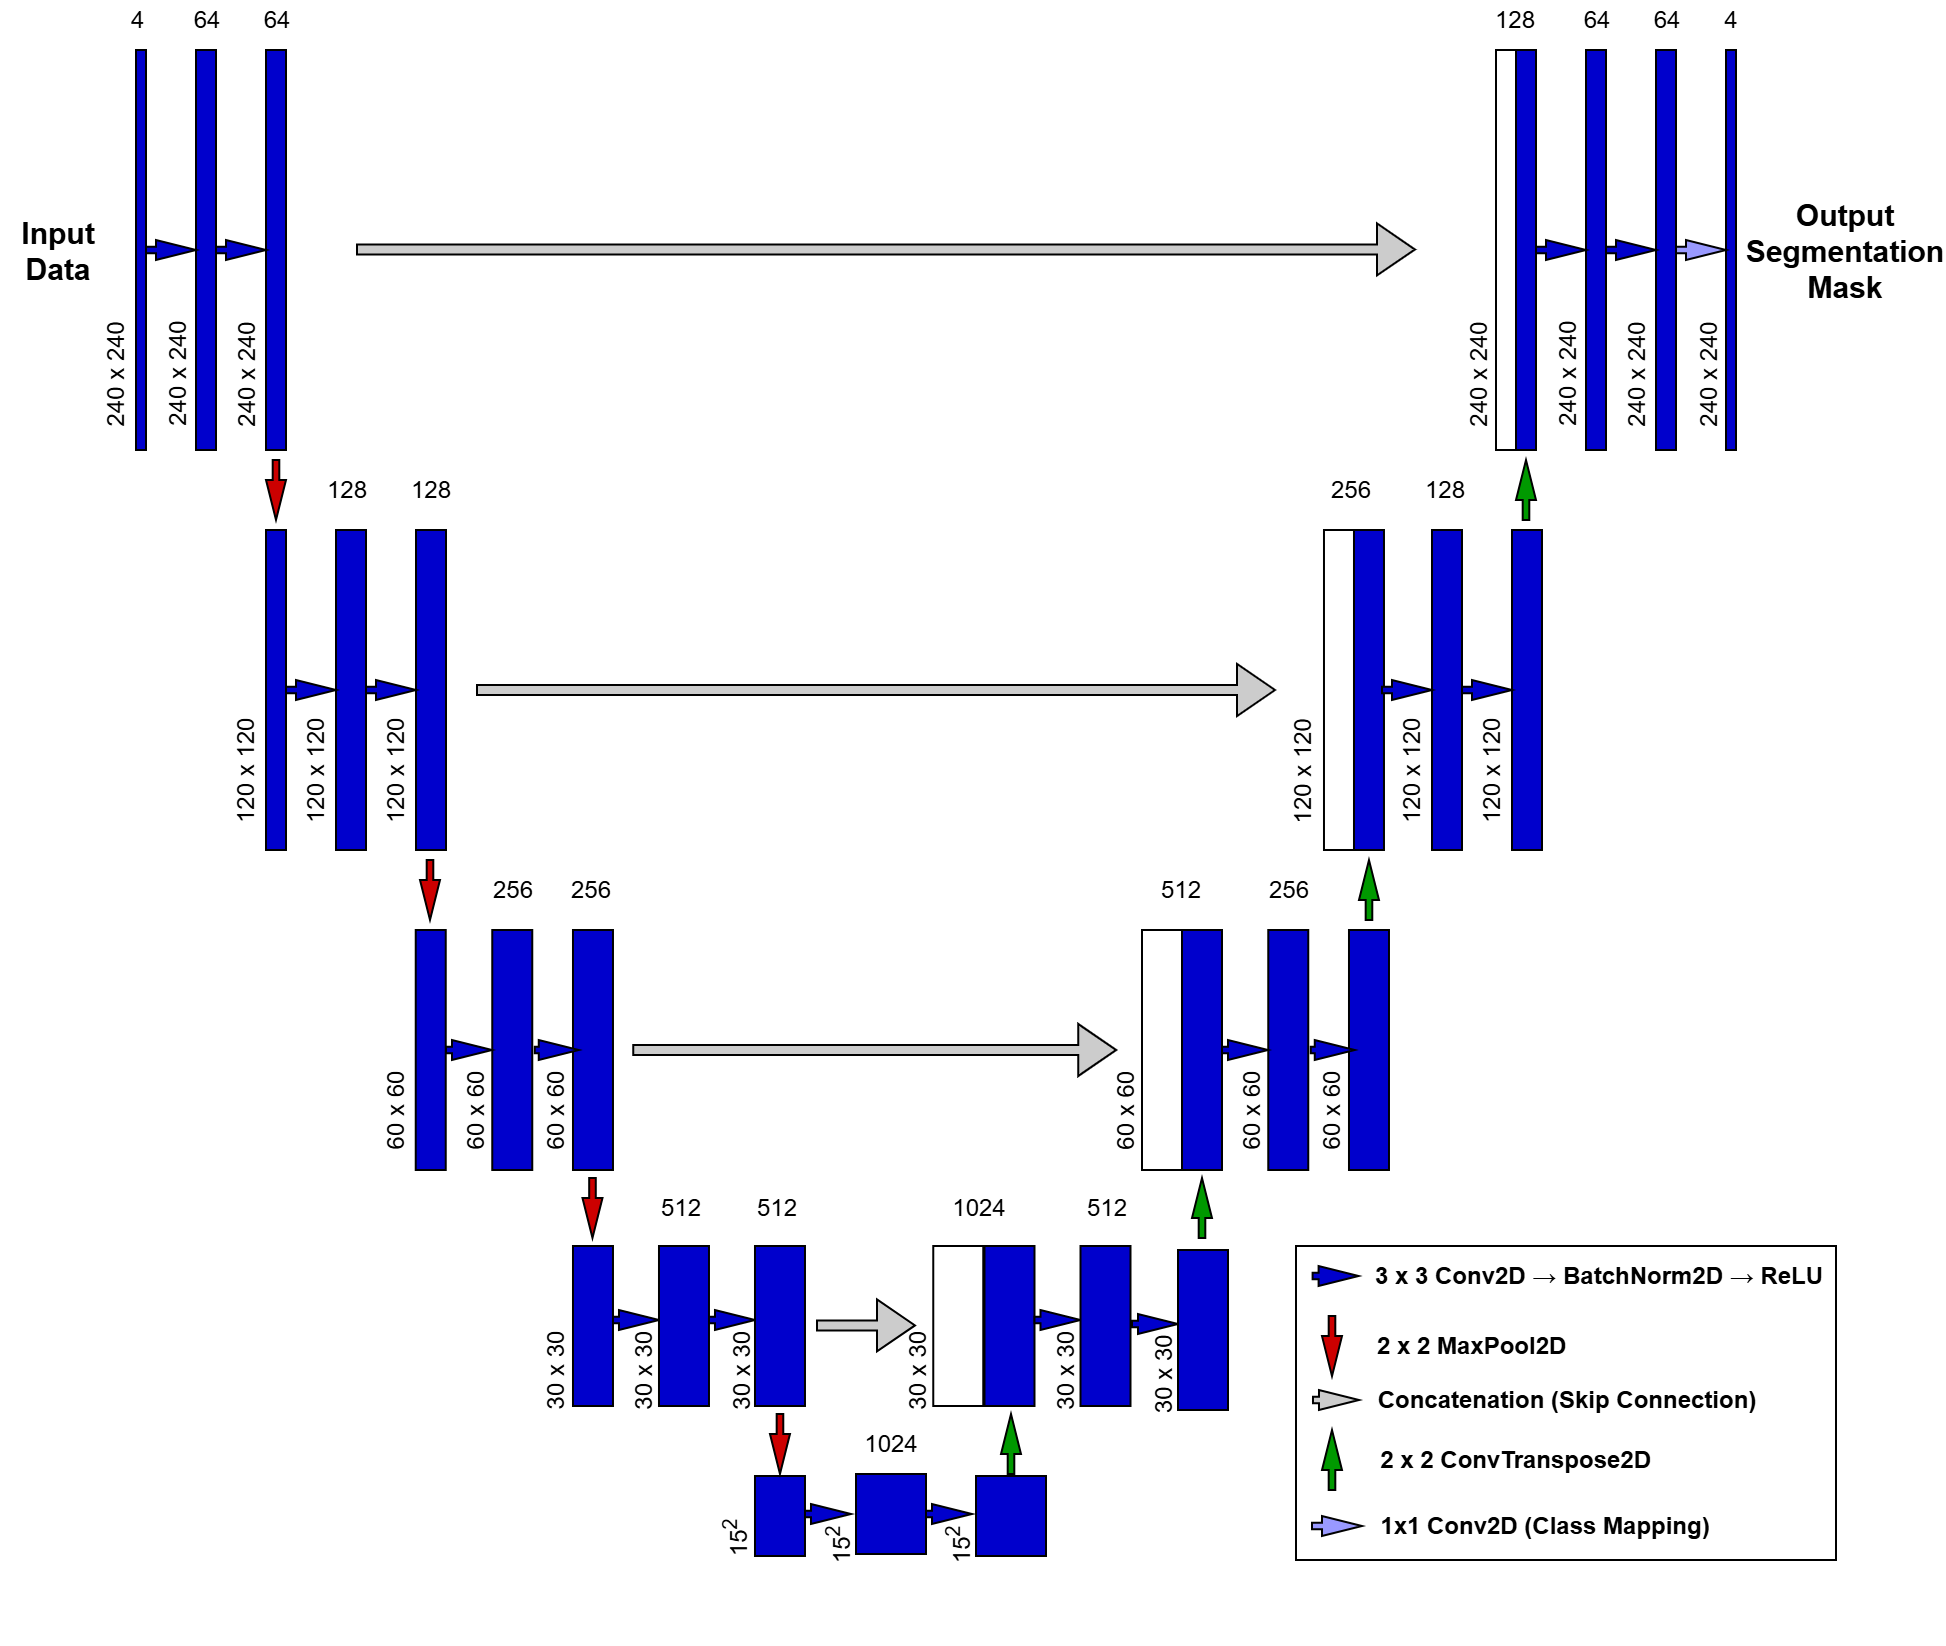

# 3️⃣ Pre-requisites






#### 3.1 Library Imports
We use nibabel for handling NIfTI medical images and torch for our U-Net implementation.

In [56]:
# Colab Specifics
from google.colab import drive, userdata

# Standard & Utilities
import os, random
from collections import defaultdict
from tqdm import tqdm
import zipfile

# Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from ipywidgets import interact, IntSlider

# Medical Imaging & ML
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


#### 3.2 Data Environment Setup: Mounting Google Drive


We will use Google Colab for this tutorial to leverage free GPU resources. First, we mount Google Drive to store our dataset and model checkpoints.

In [57]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
tutorial_data_path = "/content/drive/MyDrive/MICCAI_Tutorial_Data"

In [59]:
dataset_path = os.path.join(tutorial_data_path, "MICCAI_BraTS_2019_Data_Training")

#### 3.3 BraTS 2019 Download
**Dataset Download Link:** https://www.kaggle.com/datasets/aryashah2k/brain-tumor-segmentation-brats-2019

In the world of Medical AI, the "Gold Standard" best practice is to always download data from the official repository to ensure you have the most up-to-date and verified labels.

Since the BraTS 2019 dataset is not available through its official website (https://www.med.upenn.edu/cbica/brats2019/data.html), we will download it from Kaggle instead.

The following is a step by step process to download the dataset:




*   Login to your Kaggle account (or create a new account if you do not already have one).

*   Click on your profile picture on the top right corner
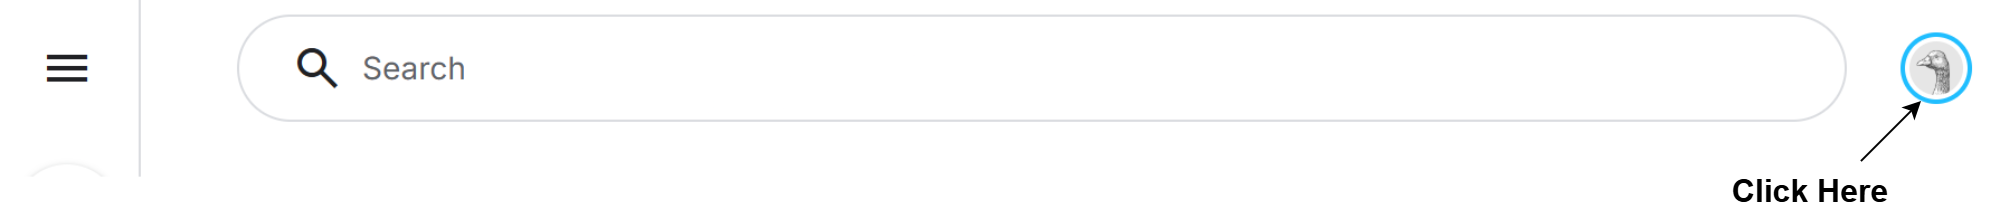

*   Click "Settings" from the available options

*   Go to the **API Tokens (Recommended)**, and click "Generate New Token" button
*   Enter the Token Name, and click the "Generate" button


*   From the dialog that appears, copy the **API TOKEN**


*   In your Google Colab Notebook, locate the key icon on the left side (tooltip text will be "Secrets"), and click it

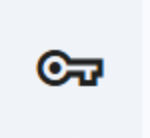

*   Add two secrets (and make sure to toggle Notebook Access to ON):

*   **Name:** KAGGLE_USERNAME | **Value:** (Paste the Kagge 'username')
*   **Name:** KAGGLE_KEY | **Value:** (Paste the copied API TOKEN)



Now run the following code cells










In [ ]:
# Install the latest Kaggle tool (as required by the new tokens)
!pip install -U kaggle

In [ ]:
# Link Colab Secrets to the environment
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
# Download and Unzip BraTS 2019
!kaggle datasets download --d aryashah2k/brain-tumor-segmentation-brats-2019

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/brain-tumor-segmentation-brats-2019
License(s): CC0-1.0
100% 2.60G/2.60G [00:35<00:00, 77.9MB/s]



Now your dataset has been downloaded to the following path:

/content/brain-tumor-segmentation-brats-2019.zip

You may verify it by looking at the zip file. Please keep in mind that this is a temporary storage and this file will be wiped out if we restart this Colab session.

Therefore, we should unzip the dataset inside our Google Drive to permanently save it. Let's unzip the file to the following destination folder:

/content/drive/MyDrive/MICCAI_Tutorial_Data

Be patient! Unzipping directly to Google Drive can take a few minutes because we are moving hundreds of high-resolution MRI scans. It’s a great time to grab a coffee ☕.

In [ ]:
source_file = "/content/brain-tumor-segmentation-brats-2019.zip"
destination_folder = tutorial_data_path

In [ ]:
# 1. Create the destination folder if it doesn't exist
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# 2. Unzip the file
print(f"Unzipping {source_file} to {destination_folder}...")
with zipfile.ZipFile(source_file, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

print("Done! Your files are now in your Google Drive.")

Unzipping /content/brain-tumor-segmentation-brats-2019.zip to /content/drive/MyDrive/MICCAI_Tutorial_Data...
Done! Your files are now in your Google Drive.


Now that we have unzipped our data, we need to make sure everything arrived correctly. Let's confirm that we have all $259$ High-Grade (HGG) and $76$ Low-Grade (LGG) patients

In [ ]:
def verify_counts(base_path, expected_hgg, expected_lgg):
    print(f"Checking folders in: {base_path}\n")

    # Check HGG
    hgg_path = os.path.join(base_path, "HGG")
    if os.path.exists(hgg_path):
        # We only count directories (folders), ignoring any hidden files
        hgg_count = len([f for f in os.listdir(hgg_path) if os.path.isdir(os.path.join(hgg_path, f))])
        status = "✅ MATCH" if hgg_count == expected_hgg else "❌ MISMATCH"
        print(f"HGG Folders: {hgg_count} (Expected: {expected_hgg}) -> {status}")
    else:
        print("❌ Error: HGG folder not found!")

    # Check LGG
    lgg_path = os.path.join(base_path, "LGG")
    if os.path.exists(lgg_path):
        lgg_count = len([f for f in os.listdir(lgg_path) if os.path.isdir(os.path.join(lgg_path, f))])
        status = "✅ MATCH" if lgg_count == expected_lgg else "❌ MISMATCH"
        print(f"LGG Folders: {lgg_count} (Expected: {expected_lgg}) -> {status}")
    else:
        print("❌ Error: LGG folder not found!")

    total = hgg_count + lgg_count
    print(f"\nTotal Patients: {total}")

In [ ]:
# Run the verification with your specific numbers
verify_counts(dataset_path, expected_hgg=259, expected_lgg=76)

Checking folders in: /content/drive/MyDrive/MICCAI_Tutorial_Data/MICCAI_BraTS_2019_Data_Training

HGG Folders: 259 (Expected: 259) -> ✅ MATCH
LGG Folders: 76 (Expected: 76) -> ✅ MATCH

Total Patients: 335


#### 3.4 Device Selection

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 4️⃣ Hands-On Code Implementation

## 4.1 Fixed Random Seed for Reproducibility

In [6]:
def set_seed(seed=42):
    """
    Sets global seeds for reproducibility across Python, NumPy, and PyTorch.
    """
    # 1. Base Python and NumPy seeds
    random.seed(seed)
    np.random.seed(seed)

    # 2. PyTorch CPU and GPU seeds
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 3. CuDNN backend settings (The "Pro" settings for GPU consistency)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"✅ Reproducibility locked! Seed set to: {seed}")

In [7]:
set_seed(42)
print("✅ Seeds set! Your data splits and model starting point are now consistent.")

✅ Reproducibility locked! Seed set to: 42
✅ Seeds set! Your data splits and model starting point are now consistent.


## 4.2 Exploratory Data Analysis (EDA)

#### Folder Structure: Navigating the BraTS 2019 Data
For this tutorial, we are using a specific version of the BraTS 2019 dataset hosted on Kaggle. It is important to note that different mirrors of this dataset may have varying folder hierarchies. To ensure the code runs successfully, your Google Drive should follow the structure below:



*   **Root Directory:** MICCAI_Tutorial_Data/

*   **Dataset Directory:** MICCAI_BraTS_2019_Data_Training/

```
MICCAI_BraTS_2019_Data_Training/
├── HGG/ (High-Grade Gliomas)
│   ├── BraTS19_2013_10_1/
│   │   ├── BraTS19_2013_10_1_flair.nii  <-- Fluid Attenuated Inversion Recovery
│   │   ├── BraTS19_2013_10_1_t1.nii     <-- T1-weighted
│   │   ├── BraTS19_2013_10_1_t1ce.nii   <-- T1-weighted Contrast Enhanced
│   │   ├── BraTS19_2013_10_1_t2.nii     <-- T2-weighted
│   │   └── BraTS19_2013_10_1_seg.nii    <-- Ground Truth Segmentation Mask
│   └── ... (Other HGG patient folders)
└── LGG/ (Low-Grade Gliomas)
    ├── BraTS19_2013_0_1/
    │   ├── BraTS19_2013_0_1_flair.nii
    │   ├── ... (Other LGG modalities)
    │   └── BraTS19_2013_0_1_seg.nii
    └── ... (Other LGG patient folders)
```

💡 **Dataset Compatibility Note**

This tutorial is optimized for the [BraTS 2019 Kaggle Dataset by Arya Shah](https://www.kaggle.com/datasets/aryashah2k/brain-tumor-segmentation-brats-2019). If you are using the official MICCAI BraTS release or a different Kaggle version, the folder nesting may differ. Please ensure your paths match the tree structure above before proceeding.



#### Dataset Statistics

In [8]:
modalities = ["t1", "t1ce", "t2", "flair"]
seg_keyword = "seg"

In [9]:
def count_dataset_statistics(dataset_path):
    stats = {}

    for tumor_class in ["HGG", "LGG"]:
        class_dir = os.path.join(dataset_path, tumor_class)
        patient_folders = [
            d for d in os.listdir(class_dir)
            if os.path.isdir(os.path.join(class_dir, d))
        ]

        stats[tumor_class] = {
            "num_patients": len(patient_folders),
            "modalities": defaultdict(int),
            "segmentation_masks": 0
        }

        for patient in patient_folders:
            patient_dir = os.path.join(class_dir, patient)
            files = os.listdir(patient_dir)

            for f in files:
                fname = f.lower()

                # Count segmentation mask
                if fname.endswith("_seg.nii") or fname.endswith("_seg.nii.gz"):
                    stats[tumor_class]["segmentation_masks"] += 1

                # Count modalities (exact match)
                for mod in modalities:
                    if fname.endswith(f"_{mod}.nii") or fname.endswith(f"_{mod}.nii.gz"):
                        stats[tumor_class]["modalities"][mod] += 1

    return stats

In [10]:
# ---- Run to compute statistics ----
stats = count_dataset_statistics(dataset_path)


In [11]:
# ---- Run to display statistics ----
for tumor_class, info in stats.items():
    print(f"\nClass: {tumor_class}")
    print(f"  Number of patients: {info['num_patients']}")
    print("  Number of files per modality:")
    for mod in modalities:
        print(f"    {mod.upper():6s}: {info['modalities'][mod]}")
    print(f"  Segmentation masks: {info['segmentation_masks']}")


Class: HGG
  Number of patients: 259
  Number of files per modality:
    T1    : 259
    T1CE  : 259
    T2    : 259
    FLAIR : 259
  Segmentation masks: 259

Class: LGG
  Number of patients: 76
  Number of files per modality:
    T1    : 76
    T1CE  : 76
    T2    : 76
    FLAIR : 76
  Segmentation masks: 76


####Visualizing the Scans: HGG vs. LGG
Now that our data is unzipped, let's take a "peek" inside the brain!

The BraTS dataset is divided into two main categories:


*   HGG (High-Grade Glioma): These are more aggressive, fast-growing tumors.
*   LGG (Low-Grade Glioma): These are typically slower-growing and less aggressive.


In the next few cells, we will randomly select one patient from each category and visualize three different "slices" of their brain. Since a brain scan is 3D (like a loaf of bread), we take slices at the $25 \%$, $50\%$, and $75\%$ marks to get a full view of the tumor's location.

In [12]:
def random_patient_path(base_dir, grade):
    grade_dir = os.path.join(base_dir, grade)
    patients = sorted(os.listdir(grade_dir))
    patient = random.choice(patients)
    return os.path.join(grade_dir, patient), patient

In [13]:
def load_brats_case(patient_dir, modality="flair"):
    files = os.listdir(patient_dir)

    #img_file = [f for f in files if modality in f.lower()][0]
    img_file = [f for f in files if f.lower().endswith(f"_{modality.lower()}.nii")][0]
    seg_file = [f for f in files if "seg" in f.lower()][0]

    img = nib.load(os.path.join(patient_dir, img_file)).get_fdata()
    seg = nib.load(os.path.join(patient_dir, seg_file)).get_fdata()

    return img, seg

In [14]:
def normalize_to_uint8(volume):
    """
    Normalize a 3D volume to uint8 [0, 255] for visualization only.
    """
    v = volume.copy()
    v = (v - v.min()) / (v.max() - v.min() + 1e-8)
    v = (v * 255).astype(np.uint8)
    return v

In [15]:
# Randomly select one HGG and one LGG patient
hgg_patient_path, hgg_patient_id = random_patient_path(dataset_path, "HGG")
lgg_patient_path, lgg_patient_id = random_patient_path(dataset_path, "LGG")

print(f"Selected HGG patient: {hgg_patient_id}")
print(f"Selected LGG patient: {lgg_patient_id}")

Selected HGG patient: BraTS19_CBICA_AQP_1
Selected LGG patient: BraTS19_2013_1_1


In [16]:
# Choose modality for visualization
modality = "t2"

# Load scans
hgg_img, hgg_seg = load_brats_case(hgg_patient_path, modality=modality)
lgg_img, lgg_seg = load_brats_case(lgg_patient_path, modality=modality)

print(f"HGG {modality.upper()} scan shape: {hgg_img.shape}")
print(f"LGG {modality.upper()} scan shape: {lgg_img.shape}")

HGG T2 scan shape: (240, 240, 155)
LGG T2 scan shape: (240, 240, 155)


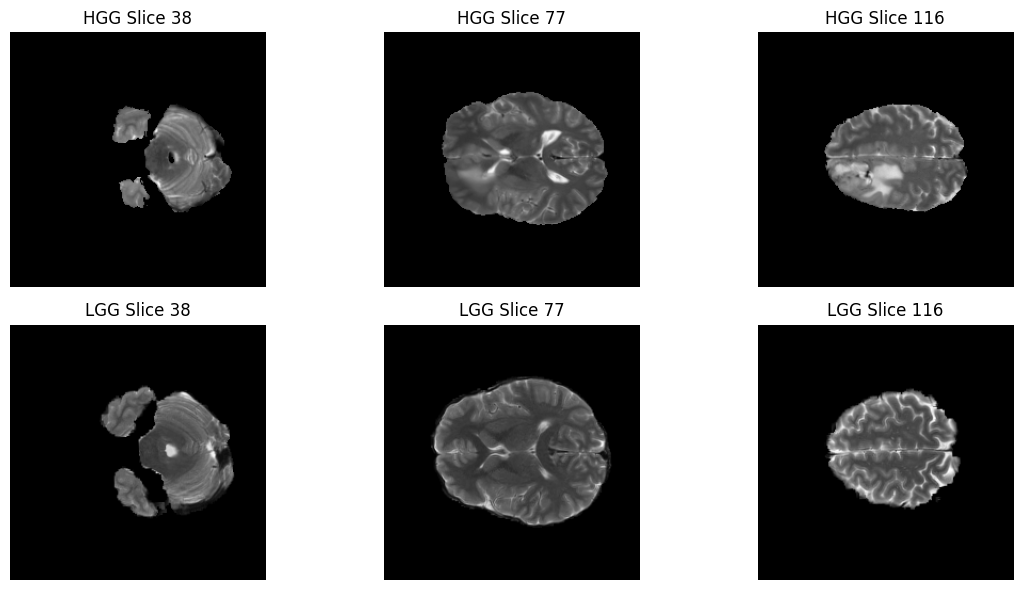

In [17]:
# Normalize for visualization
hgg_img_vis = normalize_to_uint8(hgg_img)
lgg_img_vis = normalize_to_uint8(lgg_img)

# Select 3 representative slices (25%, 50%, and 75%)
slice_indices = [
    hgg_img.shape[2] // 4,
    hgg_img.shape[2] // 2,
    3 * hgg_img.shape[2] // 4
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, z in enumerate(slice_indices):
    axes[0, i].imshow(hgg_img_vis[:, :, z], cmap="gray")
    axes[0, i].set_title(f"HGG Slice {z}")
    axes[0, i].axis("off")

    axes[1, i].imshow(lgg_img_vis[:, :, z], cmap="gray")
    axes[1, i].set_title(f"LGG Slice {z}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

#### Understanding the Segmentation Masks
In a typical photo, a pixel might represent a color. In a medical Segmentation Mask, each pixel represents a Tissue Type.

The researchers who created the BraTS dataset manually "painted" over the tumors to create these ground-truth labels. When we run the code below, we are looking for the unique values $(0, 1, 2,$ and $4)$ hidden inside the data.

Think of these numbers as a "Legend" for a map:


*   **0 (Background):** Healthy brain tissue or non-brain regions.

*   **1 (Necrotic / Non-enhancing Core):** The "dead" (necrotic) core or solid tumor tissue.

*   **2 (Edema):** The swelling around the tumor.
*   **4 (Enhancing Tumor):** The most active, growing part of the tumor.




In [18]:
print(f"HGG segmentation mask shape: {hgg_seg.shape}")
print(f"LGG segmentation mask shape: {lgg_seg.shape}")

hgg_labels = np.unique(hgg_seg)
lgg_labels = np.unique(lgg_seg)

print(f"HGG unique labels: {hgg_labels}")
print(f"LGG unique labels: {lgg_labels}")

print("\nBraTS 2019 Label Definitions:")
print("0 - Background (no tumor)")
print("1 - Necrotic / non-enhancing tumor core")
print("2 - Peritumoral edema")
print("4 - Enhancing tumor")

HGG segmentation mask shape: (240, 240, 155)
LGG segmentation mask shape: (240, 240, 155)
HGG unique labels: [0. 1. 2. 4.]
LGG unique labels: [0. 1. 2.]

BraTS 2019 Label Definitions:
0 - Background (no tumor)
1 - Necrotic / non-enhancing tumor core
2 - Peritumoral edema
4 - Enhancing tumor


#### Visualizing the Ground Truth: The Overlay
Now for the most exciting part of our data exploration: The Overlay. In medical AI, we don't just want to see the MRI; we want to see if the "labels" (the segmentation masks) align perfectly with the structures we see in the scan. By layering the colorful segmentation mask on top of the grayscale MRI, we can see exactly where the tumor core ends and the edema (swelling) begins.

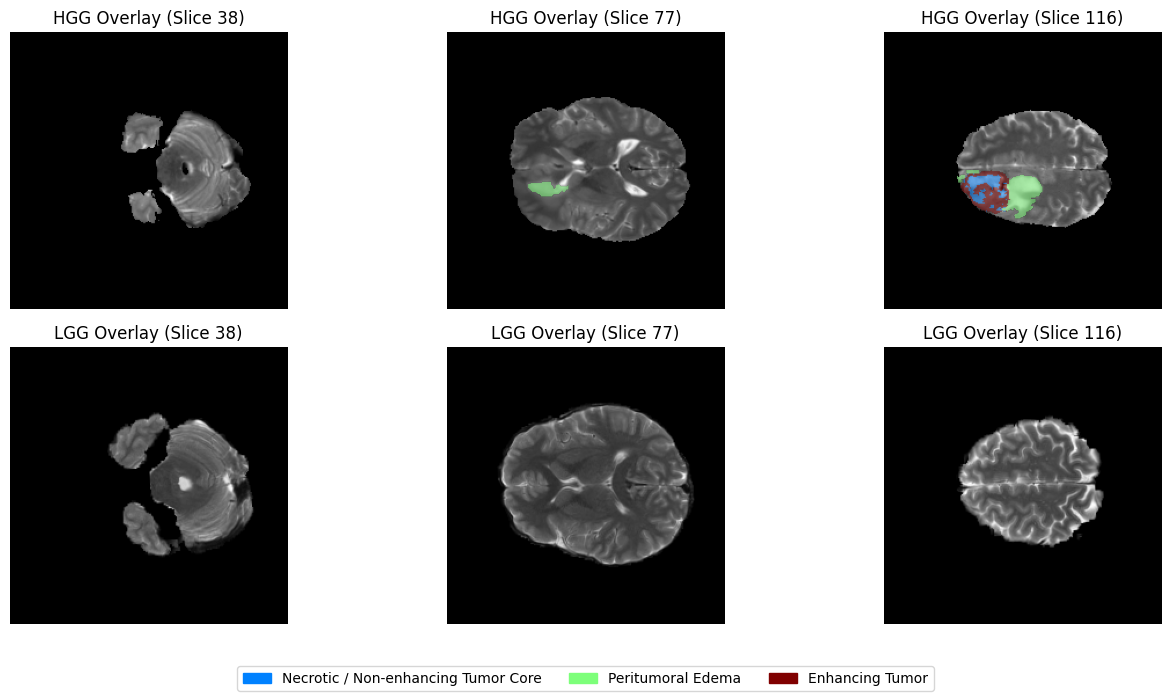

In [19]:
# Define label-to-color mapping (for legend)
label_info = {
    1: "Necrotic / Non-enhancing Tumor Core",
    2: "Peritumoral Edema",
    4: "Enhancing Tumor"
}

# Create legend patches (colors correspond to 'jet' colormap)
legend_patches = [
    mpatches.Patch(color=plt.cm.jet(1/4), label=label_info[1]),
    mpatches.Patch(color=plt.cm.jet(2/4), label=label_info[2]),
    mpatches.Patch(color=plt.cm.jet(4/4), label=label_info[4]),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, z in enumerate(slice_indices):
    # --- HGG ---
    axes[0, i].imshow(hgg_img_vis[:, :, z], cmap="gray")

    # Create a masked version of the HGG segmentation (hide 0s)
    hgg_mask_data = hgg_seg[:, :, z]
    hgg_masked = np.ma.masked_where(hgg_mask_data == 0, hgg_mask_data)

    # Plot the mask only where it is NOT 0
    axes[0, i].imshow(hgg_masked, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[0, i].set_title(f"HGG Overlay (Slice {z})")
    axes[0, i].axis("off")

    # --- LGG ---
    axes[1, i].imshow(lgg_img_vis[:, :, z], cmap="gray")

    # Create a masked version of the LGG segmentation (hide 0s)
    lgg_mask_data = lgg_seg[:, :, z]
    lgg_masked = np.ma.masked_where(lgg_mask_data == 0, lgg_mask_data)

    # Plot the mask only where it is NOT 0
    axes[1, i].imshow(lgg_masked, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[1, i].set_title(f"LGG Overlay (Slice {z})")
    axes[1, i].axis("off")

# Add legend once for the entire figure
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=10)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

#### Interactive Exploration

Static images are great, but MRI scans are 3D volumes! To truly understand the shape of a tumor, we need to travel through the different axial slices of the brain.

Below, we’ve created an interactive slider. You can slide the bar to move from the base of the skull to the top of the head. We are using a Masked Overlay technique here as well—this ensures that the healthy brain tissue remains in clear grayscale, while the tumor regions are highlighted in vibrant colors.

In [20]:
def show_slices(volume, seg, title=""):
    """
    Slider-based visualization of axial slices with normalized intensity
    and a clean, masked segmentation overlay.
    """
    volume_vis = normalize_to_uint8(volume)
    max_slice = volume_vis.shape[2] - 1

    # BraTS label definitions
    label_info = {
        1: "Necrotic / Non-enhancing Tumor Core",
        2: "Peritumoral Edema",
        4: "Enhancing Tumor"
    }

    # Create legend patches
    legend_patches = [
        mpatches.Patch(color=plt.cm.jet(1/4), label=label_info[1]),
        mpatches.Patch(color=plt.cm.jet(2/4), label=label_info[2]),
        mpatches.Patch(color=plt.cm.jet(4/4), label=label_info[4]),
    ]

    def view_slice(z):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # 1. Original grayscale image
        axes[0].imshow(volume_vis[:, :, z], cmap="gray")
        axes[0].set_title(f"{title} - Image (slice {z})")
        axes[0].axis("off")

        # 2. Clean Overlay
        axes[1].imshow(volume_vis[:, :, z], cmap="gray")

        # --- The Fix: Masking the background (0s) ---
        slice_seg = seg[:, :, z]
        masked_seg = np.ma.masked_where(slice_seg == 0, slice_seg)

        # Plot the mask with vmin/vmax to keep colors consistent
        axes[1].imshow(masked_seg, cmap="jet", alpha=0.5, vmin=0, vmax=4)
        axes[1].set_title("Segmentation Overlay")
        axes[1].axis("off")

        # Add legend
        fig.legend(
            handles=legend_patches,
            loc="lower center",
            ncol=3,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.15, 1, 1])
        plt.show()

    interact(
        view_slice,
        z=IntSlider(min=0, max=max_slice, step=1, value=max_slice // 2)
    )

In [21]:
print(f"Interactive visualization for HGG patient: {hgg_patient_id}")
show_slices(hgg_img, hgg_seg, title=f"HGG ({hgg_patient_id})")

Interactive visualization for HGG patient: BraTS19_CBICA_AQP_1


interactive(children=(IntSlider(value=77, description='z', max=154), Output()), _dom_classes=('widget-interact…

In [22]:
print(f"Interactive visualization for LGG patient: {lgg_patient_id}")
show_slices(lgg_img, lgg_seg, title=f"LGG ({lgg_patient_id})")

Interactive visualization for LGG patient: BraTS19_2013_1_1


interactive(children=(IntSlider(value=77, description='z', max=154), Output()), _dom_classes=('widget-interact…

## 4.3 Dataset Subset Selection & Preprocessing

#### Selecting a subset of the dataset

The dataset used in this tutorial is the official BraTS 2019 training set. As observed in the EDA section, the dataset contains $335$ patients ($259$ HGG and $76$ LGG) patients, with four MRI modalities per patient.

Training deep learning models on the full dataset may exceed the memory and time constraints of Google Colab’s free tier. To ensure that the tutorial runs smoothly for most learners, we recommend using a subset of the dataset.

By default, we take 10% of the total patients from each category. Due to rounding down (int truncation) in our selection logic, this results in exactly $32$ patients:


*   $25$ HGG cases ($10\%$ of $259$)
*   $7$ LGG cases ($10\%$ of $76$)

We use stratified sampling to ensure this subset maintains a proportional mix of both tumor grades. This allows the model to train within reasonable resource limits while still demonstrating the U-Net’s capabilities. Learners with access to more powerful hardware are encouraged to experiment with larger fractions or full dataset.



In [23]:
def collect_patient_data(base_dir, fraction=0.1):
    patient_data = [] # List of tuples: (path, label (HGG/LGG))

    for grade in ["HGG", "LGG"]:
        grade_dir = os.path.join(base_dir, grade)
        patients = sorted(os.listdir(grade_dir))
        patient_paths = [os.path.join(grade_dir, p) for p in patients]

        n_select = max(1, int(len(patients) * fraction))

        # Randomly select the paths
        selected_paths = np.random.choice(patient_paths, n_select, replace=False)

        # Associate each path with its grade label immediately
        for path in selected_paths:
            patient_data.append((path, grade))

    return patient_data

In [24]:
# Select a subset of patients from the full BraTS dataset
subset_fraction = 0.1  # 10% of the dataset
patient_data = collect_patient_data(dataset_path, fraction=subset_fraction)

print(f"Total selected patients: {len(patient_data)}")

# Show an example of the (path, label) structure
sample_path, sample_label = patient_data[0]
print(f"Sample Patient Path: {sample_path}")
print(f"Sample Patient Grade: {sample_label}")

Total selected patients: 32
Sample Patient Path: /content/drive/MyDrive/MICCAI_Tutorial_Data/MICCAI_BraTS_2019_Data_Training/HGG/BraTS19_CBICA_ARW_1
Sample Patient Grade: HGG


#### Strategy for Creating the Internal Train/Validation/Test Sets

The official BraTS validation set does not include segmentation masks, and the official test set is not publicly available. Therefore, in this tutorial, we create internal data splits using only the official training set.

For a dataset subset of $32$ patients, we use the following example split:


1.   Training set: $24$ patients ($75\%$)
2.   Validation set: $4$ patients ($12.5\%$)
3.   Held-out evaluation set: $4$ patients ($12.5\%$)

*These splits are used only for learning purposes, and the results should not be compared to or reported as official BraTS 2019 results.*









In [25]:
# First split: train vs (validation + held-out)
train_data, temp_data = train_test_split(
    patient_data,
    test_size=0.25,
    random_state=42,
    stratify=[d[1] for d in patient_data] # <--- Peeking at labels safely
)

# Repeat for the second split
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42,
    stratify=[d[1] for d in temp_data]
)


In [26]:
# Final Verification and Breakdown
def count_grades(data_list):
    hgg = sum(1 for _, grade in data_list if grade == "HGG")
    lgg = sum(1 for _, grade in data_list if grade == "LGG")
    return hgg, lgg

In [27]:
train_hgg, train_lgg = count_grades(train_data)
val_hgg, val_lgg = count_grades(val_data)
test_hgg, test_lgg = count_grades(test_data)

print(f"✅ Training Set:   {len(train_data)} patients (HGG: {train_hgg}, LGG: {train_lgg})")
print(f"✅ Validation Set: {len(val_data)} patients (HGG: {val_hgg}, LGG: {val_lgg})")
print(f"✅ Held-out Set:  {len(test_data)} patients (HGG: {test_hgg}, LGG: {test_lgg})")

✅ Training Set:   24 patients (HGG: 19, LGG: 5)
✅ Validation Set: 4 patients (HGG: 3, LGG: 1)
✅ Held-out Set:  4 patients (HGG: 3, LGG: 1)


#### Other Utility Methods

In [28]:
def load_nifti(path):
    return nib.load(path).get_fdata()

In [29]:
def normalize_volume(volume):
    mean = volume.mean()
    std = volume.std()
    if std == 0:
        return volume
    return (volume - mean) / std

In [30]:
def remap_labels(mask):
    """
    BraTS labels: {0, 1, 2, 4}
    Remapped to:  {0, 1, 2, 3}
    """
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask

## 4.4 Dataset Preparation for 2D U-Net

#### Slice-wise training and multi-modal input
In this tutorial, we perform 2D slice-wise brain tumor segmentation, where each training sample corresponds to a single axial slice extracted from a 3D MRI volume. For each slice, we combine the four MRI modalities (T1, T1ce, T2, and FLAIR) by stacking them along the channel dimension, resulting in a 4-channel input to the neural network. These modalities provide complementary information about brain anatomy and tumor characteristics; for example, FLAIR highlights edema, while post-contrast T1 emphasizes enhancing tumor regions. Stacking all modalities together allows the model to jointly leverage this complementary information during training.

Some axial slices at the beginning and end of each volume do not contain tumor regions. In this tutorial, we include all slices for simplicity and to reflect the natural class imbalance present in medical image segmentation tasks. More advanced pipelines often apply slice filtering or sampling strategies, which are beyond the scope of this introductory tutorial.

In [31]:
class BraTS2019SliceDataset(Dataset):
    def __init__(self, patient_data_list):
        self.samples = []

        # We unpack the tuple (path, label) here
        for patient_path, _ in patient_data_list:
            num_slices = 155
            for z in range(num_slices):
                self.samples.append((patient_path, z))

        self.cur_patient_path = None
        self.cur_volumes = None

    def _find_file(self, patient_path, keyword):
        files = os.listdir(patient_path)
        for f in files:
            # Adding "_" ensures 't1' doesn't match 't1ce'
            if f.lower().endswith(f"_{keyword.lower()}.nii") or f.lower().endswith(f"_{keyword.lower()}.nii.gz"):
                return os.path.join(patient_path, f)
        raise FileNotFoundError(f"Could not find {keyword} in {patient_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patient_path, z = self.samples[idx]

        if patient_path != self.cur_patient_path:
            self.cur_patient_path = patient_path
            self.cur_volumes = {
                "t1": normalize_volume(load_nifti(self._find_file(patient_path, "t1"))),
                "t1ce": normalize_volume(load_nifti(self._find_file(patient_path, "t1ce"))),
                "t2": normalize_volume(load_nifti(self._find_file(patient_path, "t2"))),
                "flair": normalize_volume(load_nifti(self._find_file(patient_path, "flair"))),
                "seg": remap_labels(load_nifti(self._find_file(patient_path, "seg")))
            }

        v = self.cur_volumes
        image = np.stack([v["t1"][:,:,z], v["t1ce"][:,:,z], v["t2"][:,:,z], v["flair"][:,:,z]], axis=0)
        mask = v["seg"][:,:,z]

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

#### Create train, validation, and test sets

In [32]:
train_dataset = BraTS2019SliceDataset(train_data)
val_dataset   = BraTS2019SliceDataset(val_data)
test_dataset  = BraTS2019SliceDataset(test_data)

print(f"✅ Training slices:   {len(train_dataset)}") # Expected: 24 * 155 = 3720
print(f"✅ Validation slices: {len(val_dataset)}")   # Expected: 4 * 155 = 620
print(f"✅ Held-out slices:  {len(test_dataset)}")    # Expected: 4 * 155 = 620

✅ Training slices:   3720
✅ Validation slices: 620
✅ Held-out slices:  620


#### Create dataloaders for train, validation and test sets

In [33]:
batch_size = 4  # small batch size for Colab free tier

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

#### sanity check

In [34]:
#images, masks = next(iter(train_loader))
# Use 0 workers just for the quick test to avoid the multiprocessing warning
test_loader_debug_2 = DataLoader(train_dataset, batch_size=4, num_workers=0)
data_iter = iter(test_loader_debug_2)

for i in range(2):
  images, masks = next(data_iter)

  print("Image batch shape:", images.shape)  # (B, 4, H, W)
  print("Mask batch shape:", masks.shape)    # (B, H, W)
  print("Unique labels:", torch.unique(masks))

Image batch shape: torch.Size([4, 4, 240, 240])
Mask batch shape: torch.Size([4, 240, 240])
Unique labels: tensor([0])
Image batch shape: torch.Size([4, 4, 240, 240])
Mask batch shape: torch.Size([4, 240, 240])
Unique labels: tensor([0])


## 4.5 2D U-Net Model Implementation

We implement a modernized version of the original 4-level U-Net architecture. While we follow the original symmetric design, we include Batch Normalization and Same Padding to stabilize training and maintain consistent spatial dimensions—standard practices in contemporary medical AI. Although we train on a small subset of the dataset for demonstration purposes, using the standard architecture helps illustrate the full design of U-Net. In practice, model depth and capacity can be adjusted depending on dataset size and computational resources.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class UNet2D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4):
        super().__init__()

        # -------- Encoder --------
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2)

        # -------- Bottleneck --------
        self.bottleneck = DoubleConv(512, 1024)

        # -------- Decoder --------
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # -------- Output --------
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

In [ ]:
model = UNet2D(
    in_channels=4,   # T1, T1ce, T2, FLAIR
    num_classes=4    # background + tumor subregions
).to(device)

print(model)

UNet2D(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block):

#### Loss Function Definition

In brain tumor segmentation, we face a severe class imbalance problem: the background (Class 0) occupies most of the image, while tumor regions (Classes 1–3) are relatively small and can be easily overlooked by the model.

To address this, we use a hybrid Dice + Cross Entropy (DiceCE) loss, which combines:


*   **Cross Entropy Loss** — provides stable pixel-wise supervision and helps
with class discrimination
*   **Dice Loss** — directly optimizes region overlap and is less sensitive to class imbalance

In our implementation, the model outputs raw logits, which are converted into class probabilities using the Softmax function before computing the Dice term.

For the multi-class case, the Dice score is computed per class and then averaged:
$$
L_{DiceCE} = \lambda \cdot L_{CE} + (1 - \lambda) \cdot \left(1 - \frac{1}{C} \sum_{c=1}^{C} \frac{2 \sum_i p_{i,c} g_{i,c} + \epsilon}{\sum_i p_{i,c} + \sum_i g_{i,c} + \epsilon} \right)
$$
where:


*   $p_{i,c}$ is the predicted probability for class $c$ at pixel $i$
*   $g_{i,c}$ is the one-hot encoded ground truth


*   $C$ is the number of classes
*   $ϵ$ is a small constant for numerical stability

In this tutorial, we use an equal weighting ($𝜆=0.5$), which is a common and effective choice in practice.



In [ ]:
class DiceCELoss(nn.Module):
    def __init__(self, num_classes=4, smooth=1e-6):
        super(DiceCELoss, self).__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        # Cross Entropy is excellent for global class relations
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        """
        inputs: raw logits from model (B, C, H, W)
        targets: class indices (B, H, W)
        """
        # 1. Compute Cross Entropy Loss
        ce_loss = self.ce(inputs, targets)

        # 2. Compute Soft Dice Loss
        probs = F.softmax(inputs, dim=1)

        # We create the one-hot tensor and immediately move it to the
        # same device as the model inputs (CPU or GPU)
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        targets_one_hot = targets_one_hot.to(inputs.device)

        # Sum over Batch, Height, and Width
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        # Compute Dice Score and then Dice Loss (1 - Score)
        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        dice_loss = 1 - torch.mean(dice_score)

        # 3. Hybrid Weighting (Note: A 50/50 weighting is a common and effective choice, but not universally optimal.)
        return 0.5 * ce_loss + 0.5 * dice_loss



#### Hyperparameter Setting

In [ ]:
criterion = DiceCELoss(num_classes=4)
learning_rate = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-5
)
num_epochs = 1

#### Sanity Check

In [ ]:
# Take one batch from the training loader
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Forward pass
outputs = model(images)

print("Input shape :", images.shape)   # (B, 4, H, W)
print("Output shape:", outputs.shape)  # (B, 4, H, W)
print("Mask shape  :", masks.shape)    # (B, H, W)

Input shape : torch.Size([4, 4, 240, 240])
Output shape: torch.Size([4, 4, 240, 240])
Mask shape  : torch.Size([4, 240, 240])


##4.6 Training & Evaluation for 2D U-Net

####Training Loop

In [ ]:
def train_unet(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    save_path
):
    best_val_loss = float('inf') # Added to track progress

    for epoch in range(num_epochs):
        # --------------------
        # Training phase
        # --------------------
        model.train()
        train_loss = 0.0

        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        #for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        for images, masks in pbar_train:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)          # (B, C, H, W)
            loss = criterion(outputs, masks) # masks: (B, H, W)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar_train.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= len(train_loader)

        # --------------------
        # Validation phase
        # --------------------
        model.eval()
        val_loss = 0.0

        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        with torch.no_grad():
            #for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            for images, masks in pbar_val:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        # --------------------
        # Save Best Model
        # --------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"--> Model improved! Saved to {save_path}")

        # --------------------
        # Epoch summary
        # --------------------
        print(
            f"\n Epoch [{epoch+1}/{num_epochs}] "
            f"\n Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

In [ ]:
checkpoint_path_2d = os.path.join(tutorial_data_path, "best_model_2d.pth")

train_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    save_path = checkpoint_path_2d
)


Epoch 1/1 [Val]: 100%|██████████| 155/155 [00:42<00:00,  3.64it/s]


--> Model improved! Saved to /content/drive/MyDrive/MICCAI_Tutorial_Data/best_model_2d.pth

 Epoch [1/1] 
 Train Loss: 0.5437 | Val Loss: 0.3862


#### Evaluation of the Trained Model

We evaluate the model using the **Dice score**, which measures the overlap between predicted segmentations and ground truth masks. Dice scores are computed separately for each tumor subregion, and the background class is excluded.

For a given class \( $c$ \), we first convert the predicted segmentation and ground truth into binary masks:

$$
P_c(i) =
\begin{cases}
1 & \text{if } \text{pred}(i) = c \\
0 & \text{otherwise}
\end{cases}
\qquad
G_c(i) =
\begin{cases}
1 & \text{if } \text{target}(i) = c \\
0 & \text{otherwise}
\end{cases}
$$

The Dice score for class \( $c$ \) on a 2D slice is then computed as:

$$
\text{Dice}_c =
\frac{2 \sum_i P_c(i)\, G_c(i)}
{\sum_i P_c(i) + \sum_i G_c(i) + \epsilon}
$$

where $ i $ indexes all pixels in the slice and  $\epsilon$ is a small constant (e.g., $10^{-6}$) for numerical stability.

If a class is absent in both prediction and ground truth, i.e.,

$$
\sum_i P_c(i) + \sum_i G_c(i) = 0,
$$

the Dice score is undefined and treated as $\mathrm{NaN}$. Such slices are excluded from averaging.

---

Since the model is trained slice-wise, Dice is computed on individual 2D slices. For each class $ c $, we average Dice scores only over slices where the Dice score is defined (i.e., where the class is present in at least one of prediction or ground truth):

$$
\overline{\text{Dice}}_c =
\frac{1}{N_c} \sum_{k \in \mathcal{V}_c} \text{Dice}_c^{(k)}
$$

where:
- $ k $ indexes slices  
- $\mathcal{V}_c$ is the set of valid slices ($\mathrm{non-NaN}$ Dice)  
- $N_c = |\mathcal{V}_c|$

---

Finally, the overall mean Dice score is computed by averaging across all tumor classes (excluding background):

$$
\text{Mean Dice} =
\frac{1}{C} \sum_{c=1}^{C} \overline{\text{Dice}}_c
$$

where $ C $ is the number of tumor classes (3 in BraTS).

---

While this slice-wise evaluation is consistent with the training setup, most research works report Dice scores computed over full 3D volumes.

In [ ]:
def multiclass_dice(pred, target, num_classes=4, ignore_background=True):
    """
    pred, target: (H, W) tensors with class indices
    """
    dice_scores = {}
    classes = range(1, num_classes) if ignore_background else range(num_classes)

    for cls in classes:
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        if denominator == 0:
            dice = torch.tensor(float('nan'))
        else:
            dice = (2.0 * intersection) / (denominator + 1e-6)

        dice_scores[cls] = dice.item()

    return dice_scores

In [ ]:
def evaluate_model(model, dataloader, device, num_classes=4):
    model.eval()

    dice_accumulator = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)              # (B, C, H, W)
            preds = torch.argmax(outputs, dim=1) # (B, H, W)

            for b in range(preds.size(0)):
                dice_scores = multiclass_dice(
                    preds[b],
                    masks[b],
                    num_classes=num_classes,
                    ignore_background=True
                )

                for cls, score in dice_scores.items():
                    dice_accumulator[cls].append(score)

    # Compute mean Dice per class
    #mean_dice = {
    #    cls: sum(scores) / len(scores) if len(scores) > 0 else 0.0
    #    for cls, scores in dice_accumulator.items()
    #}

    #--- UPDATED AVERAGING LOGIC ---
    mean_dice = {}
    for cls, scores in dice_accumulator.items():
        # Filter out NaN values (empty slices)
        valid_scores = [s for s in scores if not np.isnan(s)]

        if len(valid_scores) > 0:
            mean_dice[cls] = sum(valid_scores) / len(valid_scores)
        else:
            # If a class was NEVER present in any slice (highly unlikely for BraTS)
            mean_dice[cls] = 0.0

    # Compute overall mean Dice
    overall_mean_dice = sum(mean_dice.values()) / len(mean_dice)

    return mean_dice, overall_mean_dice

In [ ]:
mean_dice, overall_dice = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=device,
    num_classes=4
)

# Mapping to make the results more "clinical"
brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("Dice score per class (excluding background):")
for cls, score in mean_dice.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall Mean Dice (Across all tumor regions): {overall_dice:.4f}")

Dice score per class (excluding background):
  Necrotic / Non-enhancing Core (NCR/NET): 0.1990
  Edema (ED): 0.4864
  Enhancing Tumor (ET): 0.4895

Overall Mean Dice (Across all tumor regions): 0.3916


#### Volume-wise Dice Score (Patient-level Evaluation)
In medical image segmentation challenges such as BraTS, evaluation is typically performed at the patient (3D volume) level, rather than slice-by-slice.

Although our 2D U-Net processes images slice-wise during training and inference, its predictions can be reconstructed into a full 3D segmentation volume by stacking slice predictions.

For a given class $ c $, we define binary masks over the full 3D volume:

$$
P_c(i) =
\begin{cases}
1 & \text{if } \text{pred}(i) = c \\
0 & \text{otherwise}
\end{cases}
\qquad
G_c(i) =
\begin{cases}
1 & \text{if } \text{target}(i) = c \\
0 & \text{otherwise}
\end{cases}
$$

where $ i $ indexes all voxels in the 3D volume.

The Dice score for class $ c $ for a given patient is computed as:

$$
\text{Dice}_c =
\frac{2 \sum_i P_c(i)\, G_c(i)}
{\sum_i P_c(i) + \sum_i G_c(i) + \epsilon}
$$

where $\epsilon $ is a small constant (e.g., $10^{-6}$) for numerical stability.

If a class is absent in both prediction and ground truth, i.e.,

$$
\sum_i P_c(i) + \sum_i G_c(i) = 0,
$$

the Dice score is undefined and treated as $\mathrm{NaN}$. Such cases are excluded from averaging.

---

We compute Dice scores:
- per class  
- on the entire 3D volume of each patient  

Then, for each class $ c $, we average Dice scores across patients:

$$
\overline{\text{Dice}}_c =
\frac{1}{N_c} \sum_{p \in \mathcal{P}_c} \text{Dice}_c^{(p)}
$$

where:
- $ p $ indexes patients  
- $ \mathcal{P}_c $ is the set of patients for which Dice is valid ($\mathrm{non-NaN}$)  
- $ N_c = |\mathcal{P}_c| $

---

Finally, the overall mean Dice score is computed by averaging across all tumor classes (excluding background):

$$
\text{Mean Dice} =
\frac{1}{C} \sum_{c=1}^{C} \overline{\text{Dice}}_c
$$

where $ C $ is the number of tumor classes (3 in BraTS).

---

This evaluation protocol is closer to how segmentation models are assessed in research and benchmark challenges.


#### Note on 2D-to-3D Reconstruction Artifacts

Because the model only sees one slice at a time, it lacks spatial context in the third dimension ($Z$-axis). Consequently, the predicted boundaries can 'jump' or appear jagged when viewed from a sagittal or coronal perspective—a common limitation that 3D U-Nets naturally solve.







In [ ]:
def volume_dice_per_patient(model, patient_dirs, device, num_classes=4):
    """
    Compute volume-wise Dice score per patient and average across patients.
    """

    model.eval()

    # Store Dice scores per class for each patient
    patient_dice_scores = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for patient_dir in patient_dirs:

            # -------- Load modalities --------
            t1 = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t1.nii" in f.lower()][0])
            ))
            t1ce = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t1ce.nii" in f.lower()][0])
            ))
            t2 = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t2.nii" in f.lower()][0])
            ))
            flair = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "flair.nii" in f.lower()][0])
            ))

            seg = load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "seg" in f.lower()][0])
            )
            seg = remap_labels(seg)

            # Stack modalities
            volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)

            # -------- Predict full volume --------
            preds_volume = []

            for z in range(seg.shape[2]):
                slice_img = torch.tensor(
                    volume[:, :, :, z],
                    dtype=torch.float32
                ).unsqueeze(0).to(device)

                output = model(slice_img)
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
                preds_volume.append(pred)

            preds_volume = np.stack(preds_volume, axis=2)

            # -------- Compute Dice per class (volume-level) --------
            for cls in range(1, num_classes):

                pred_c = (preds_volume == cls)
                target_c = (seg == cls)

                intersection = (pred_c & target_c).sum()
                denominator = pred_c.sum() + target_c.sum()

                if denominator == 0:
                    #dice = 1.0
                    dice = np.nan
                else:
                    dice = (2.0 * intersection) / (denominator + 1e-6)

                patient_dice_scores[cls].append(dice)

    # -------- Average across patients --------
    #mean_dice = {
    #    cls: np.mean(scores) if len(scores) > 0 else 0.0
    #    for cls, scores in patient_dice_scores.items()
    #}

    # -------- Average across patients (NaN-aware) --------
    mean_dice = {}
    for cls, scores in patient_dice_scores.items():
        # Remove NaNs before averaging
        valid_scores = [s for s in scores if not np.isnan(s)]
        if len(valid_scores) > 0:
            mean_dice[cls] = np.mean(valid_scores)
        else:
            mean_dice[cls] = 0.0

    overall_mean_dice = np.mean(list(mean_dice.values()))

    return mean_dice, overall_mean_dice

In [ ]:
brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

test_patient_paths = [item[0] for item in test_data]

mean_dice_vol, overall_dice_vol = volume_dice_per_patient(
    model=model,
    patient_dirs=test_patient_paths, # Using test_patients for final report
    device=device,
    num_classes=4
)

print("Final Volumetric Dice Scores (3D Reconstruction):")
for cls, score in mean_dice_vol.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Mean Dice: {overall_dice_vol:.4f}")

Final Volumetric Dice Scores (3D Reconstruction):
  Necrotic / Non-enhancing Core (NCR/NET): 0.3342
  Edema (ED): 0.6180
  Enhancing Tumor (ET): 0.5298

Overall 3D Mean Dice: 0.4940


## 4.7 Visualization of Results (2D U-Net)

#### Selecting samples for visualization
Randomly select one patient from the held-out set for qualitative evaluation. Since the held-out set is small in this tutorial setting, visualizing a single representative case is sufficient to demonstrate the workflow.

In [ ]:
# Randomly select one patient from the held-out set
test_patient_paths = [item[0] for item in test_data]

viz_patient_dir = random.choice(test_patient_paths)
viz_patient_id = os.path.basename(viz_patient_dir)

print(f"Selected patient for visualization: {viz_patient_id}")

Selected patient for visualization: BraTS19_CBICA_AOZ_1


#### Load modalities and ground truth

In [ ]:
# Load and normalize modalities
t1 = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t1.nii" in f.lower()][0])))
t1ce = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t1ce.nii" in f.lower()][0])))
t2 = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t2.nii" in f.lower()][0])))
flair = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "flair.nii" in f.lower()][0])))

# Load and remap segmentation mask
seg = load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "seg" in f.lower()][0]))
seg = remap_labels(seg)

# Stack modalities into (4, H, W, D)
volume = np.stack([t1, t1ce, t2, flair], axis=0)

print("Volume shape:", volume.shape)
print("Segmentation shape:", seg.shape)

Volume shape: (4, 240, 240, 155)
Segmentation shape: (240, 240, 155)


#### Run inference on all slices

In [ ]:
model.eval()
predictions = []

with torch.no_grad():
    for z in range(seg.shape[2]):
        slice_img = torch.tensor(volume[:, :, :, z], dtype=torch.float32).unsqueeze(0).to(device)
        output = model(slice_img)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        predictions.append(pred)

predictions = np.stack(predictions, axis=2)

print("Prediction volume shape:", predictions.shape)

Prediction volume shape: (240, 240, 155)


#### Visualizing predictions vs ground truth (slice-wise)
From the selected patient, randomly select a few axial slices that contain tumor regions. For each slice, display:


*   Left: Input MRI slice
*   Middle: Ground truth segmentation mask
*   Right: Model-predicted segmentation mask

This side-by-side comparison allows a direct qualitative assessment of segmentation performance.

####Select slices that contain tumor regions

In [ ]:
# Identify slices containing tumor
tumor_slices = [z for z in range(seg.shape[2]) if np.any(seg[:, :, z] > 0)]

print(f"Number of slices containing tumor: {len(tumor_slices)}")

# Randomly select a few slices
num_slices_to_show = 3
selected_slices = random.sample(tumor_slices, min(num_slices_to_show, len(tumor_slices)))

print("Selected slice indices:", selected_slices)

Number of slices containing tumor: 89
Selected slice indices: [117, 100, 42]


#### Side-by-side visualization

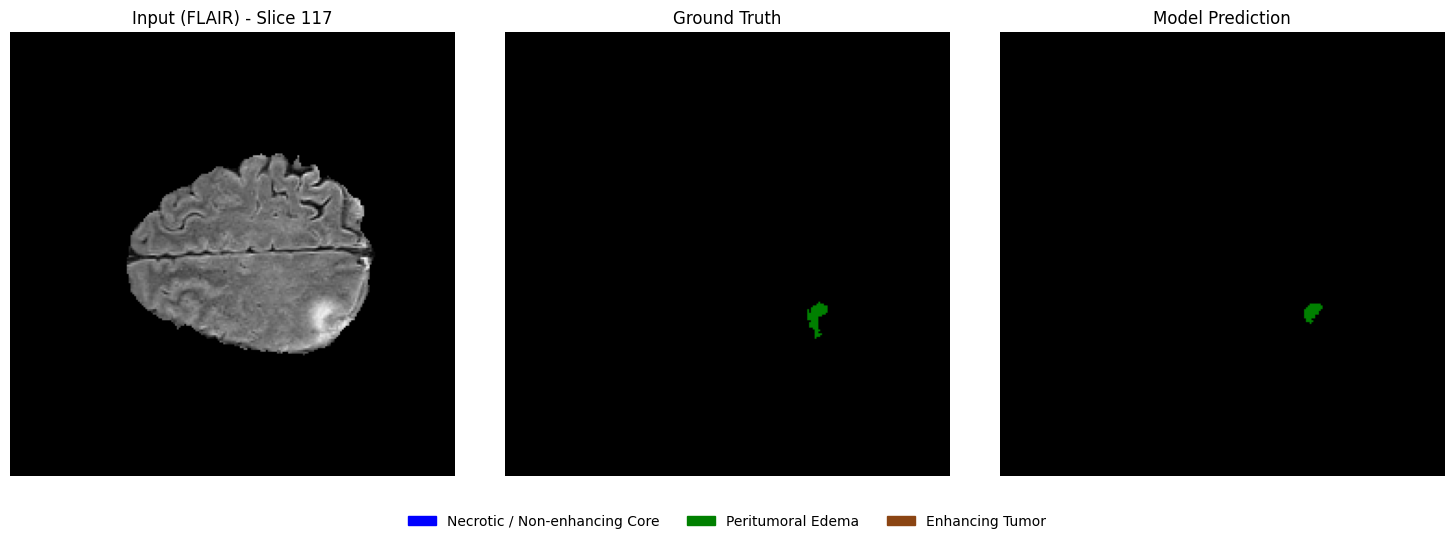

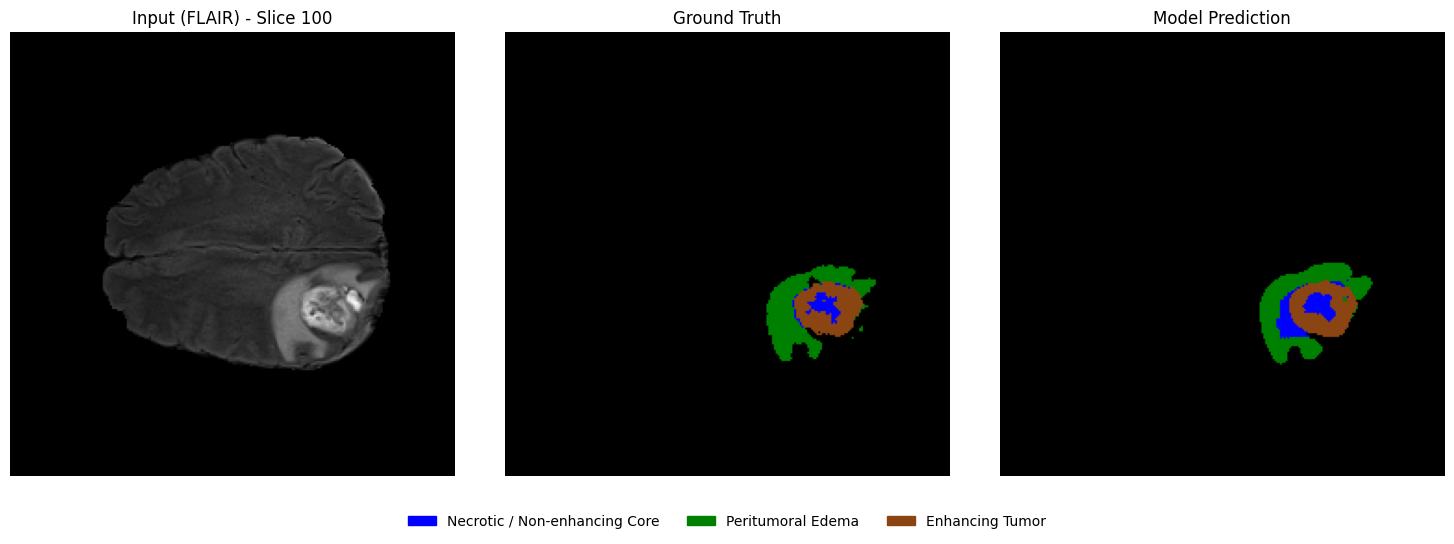

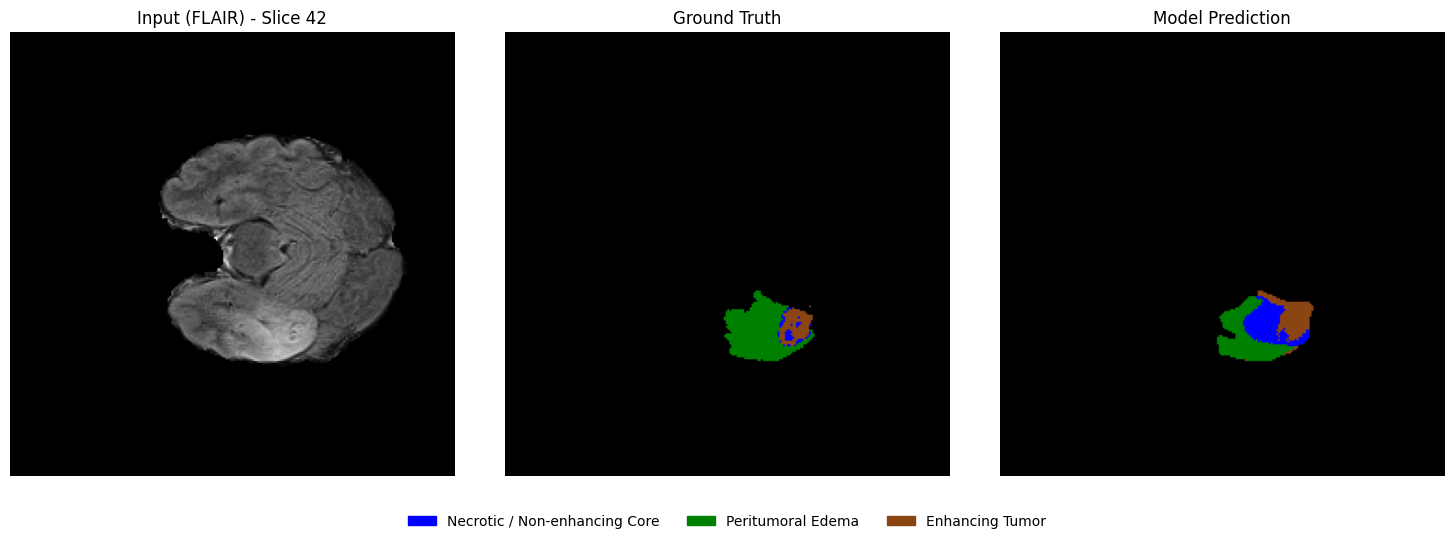

In [ ]:
# 1. Define the Consistent EDA-style Colormap (Matches Overlay)
# 0: Black, 1: Blue (NCR), 2: Green (ED), 3: Brown (ET)
eda_consistent_colors = ['black', 'blue', 'green', 'saddlebrown']
my_cmap = ListedColormap(eda_consistent_colors)

# 2. Create the legend patches to match EDA descriptions
legend_labels = {
    "Necrotic / Non-enhancing Core": "blue",
    "Peritumoral Edema": "green",
    "Enhancing Tumor": "saddlebrown"
}
patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]

# 3. Visualization loop
for z in selected_slices:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- Panel 1: Input FLAIR ---
    axes[0].imshow(flair[:, :, z], cmap="gray")
    axes[0].set_title(f"Input (FLAIR) - Slice {z}")
    axes[0].axis("off")

    # --- Panel 2: Ground Truth ---
    # vmin/vmax ensures 0=black, 1=blue, 2=green, 3=brown
    axes[1].imshow(seg[:, :, z], cmap=my_cmap, vmin=0, vmax=3)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # --- Panel 3: Model Prediction ---
    axes[2].imshow(predictions[:, :, z], cmap=my_cmap, vmin=0, vmax=3)
    axes[2].set_title("Model Prediction")
    axes[2].axis("off")

    # --- Unified Legend (Centered at bottom of the row) ---
    fig.legend(
        handles=patches,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=3,
        fontsize=10,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

#### Overlaying predictions on MRI images
Using the same slices, overlay the predicted segmentation masks on the corresponding MRI slices in grayscale with transparency. This visualization helps assess the spatial alignment of predictions with anatomical structures.

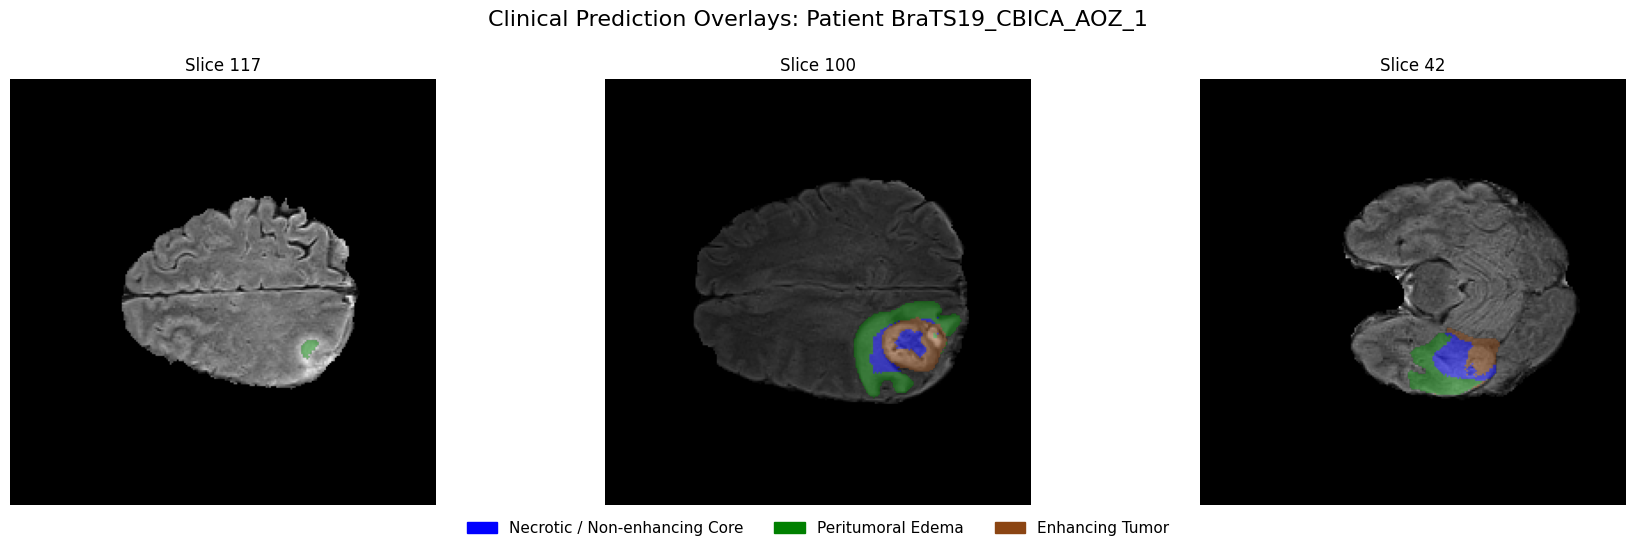

In [ ]:
# 1. Define the EDA-consistent colors
# Blue: Necrotic / Non-enhancing Core (1), Green: Edema (2), Brown: Enhancing (3)
legend_patches = [
    mpatches.Patch(color="blue", label="Necrotic / Non-enhancing Core"),
    mpatches.Patch(color="green", label="Peritumoral Edema"),
    mpatches.Patch(color="saddlebrown", label="Enhancing Tumor"),
]
overlay_cmap = ListedColormap(["blue", "green", "saddlebrown"])

# 2. Setup the horizontal figure (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, z in enumerate(selected_slices):
    # --- Step 1: Plot the Grayscale MRI Base ---
    axes[i].imshow(flair[:, :, z], cmap="gray")

    # --- Step 2: Create a Masked Prediction Volume ---
    # Masking 0s ensures the background remains grayscale FLAIR
    pred_slice = predictions[:, :, z]
    masked_preds = np.ma.masked_where(pred_slice == 0, pred_slice)

    # --- Step 3: Overlay with Alpha for Transparency ---
    # vmin=1, vmax=3 maps the labels to our blue-green-brown list
    axes[i].imshow(masked_preds, cmap=overlay_cmap, alpha=0.5, vmin=1, vmax=3)

    axes[i].set_title(f"Slice {z}", fontsize=12)
    axes[i].axis("off")

# --- Step 4: Unified Legend for the entire Row ---
fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    fontsize=11,
    frameon=False
)

plt.suptitle(f"Clinical Prediction Overlays: Patient {viz_patient_id}", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.1, 1, 0.92]) # Adjust layout to fit Title and Legend
plt.show()

## 4.8 Dataset Preparation for 3D U-Net

While 2D U-Nets are efficient, they lack the Z-axis spatial context necessary to fully understand 3D anatomical structures. To solve the inter-slice incoherence problem, we now transition to a 3D Patch-based pipeline.



#### The Challenge: Memory vs. Context

Processing a full BraTS volume ($240 \times 240 \times 155$) in 3D creates a significantly higher memory footprint than 2D slices. Attempting to load and train on full volumes can easily exhaust the VRAM of standard GPUs (like the NVIDIA T4). To overcome this, we implement a Patch-based Dataset:


*   Random Spatial Cropping: During training, we extract sub-volumes (patches) of size $64 \times 64 \times 64$ from random locations. This introduces variability across epochs—effectively acting as a form of data augmentation—while also keeping memory usage low.

*   Center Cropping: For validation and testing, we use a fixed center patch to ensure reproducible and consistent evaluation metrics.
*   Multimodal Stacking: We maintain our 4-channel input (T1, T1ce, T2, FLAIR). The resulting tensor shape for the model input becomes $(C, D, H, W)$, where $C=4$.





In [31]:
class BraTS3DDataset(Dataset):
    def __init__(self, patient_data_list, patch_size=(64, 64, 64), training=True):
        """
        patient_data_list: List of tuples [(path, label), ...]
        patch_size: (D, H, W) dimensions for the sub-volume
        """
        self.samples = patient_data_list # Consistent with 2D structure
        self.patch_size = patch_size
        self.training = training

    def __len__(self):
        return len(self.samples)

    def _find_file(self, patient_path, keyword):
        """Consistent with 2D _find_file logic"""
        files = os.listdir(patient_path)
        for f in files:
            # Matches '_t1.nii' or '_t1.nii.gz' specifically
            if f.lower().endswith(f"_{keyword.lower()}.nii") or f.lower().endswith(f"_{keyword.lower()}.nii.gz"):
                return os.path.join(patient_path, f)
        raise FileNotFoundError(f"Could not find {keyword} in {patient_path}")

    def __getitem__(self, idx):
        # Unpack the tuple (consistent with 2D calling code)
        patient_path, _ = self.samples[idx]

        # 1. Load modalities
        t1 = normalize_volume(load_nifti(self._find_file(patient_path, "t1")))
        t1ce = normalize_volume(load_nifti(self._find_file(patient_path, "t1ce")))
        t2 = normalize_volume(load_nifti(self._find_file(patient_path, "t2")))
        flair = normalize_volume(load_nifti(self._find_file(patient_path, "flair")))
        seg = remap_labels(load_nifti(self._find_file(patient_path, "seg")))

        # 2. Stack sequences: (4, H, W, D)
        image = np.stack([t1, t1ce, t2, flair], axis=0)
        image = np.transpose(image, (0, 3, 1, 2))        # (4, D, H, W)

        mask = seg[np.newaxis, :, :, :] # Add channel dim for cropping logic
        mask = np.transpose(mask, (0, 3, 1, 2))        # (1, D, H, W)

        # 3. Crop to Patch
        if self.training:
            image, mask = self._random_spatial_crop(image, mask)
        else:
            image, mask = self._center_spatial_crop(image, mask)

        # Return (4, D, H, W) image and (D, H, W) mask
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask[0], dtype=torch.long)

    def _random_spatial_crop(self, img, mask):
        d, h, w = img.shape[1:]
        z = np.random.randint(0, d - self.patch_size[0] + 1)
        y = np.random.randint(0, h - self.patch_size[1] + 1)
        x = np.random.randint(0, w - self.patch_size[2] + 1)

        img_patch = img[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        mask_patch = mask[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        return img_patch, mask_patch

    def _center_spatial_crop(self, img, mask):
        d, h, w = img.shape[1:]
        z = (d - self.patch_size[0]) // 2
        y = (h - self.patch_size[1]) // 2
        x = (w - self.patch_size[2]) // 2

        img_patch = img[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        mask_patch = mask[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        return img_patch, mask_patch

In [32]:
# Configuration for 3D
patch_size_3d = (64, 64, 64)

# Passing the same lists used in 2D
train_dataset_3d = BraTS3DDataset(train_data, patch_size=patch_size_3d, training=True)
val_dataset_3d   = BraTS3DDataset(val_data,   patch_size=patch_size_3d, training=False)
test_dataset_3d  = BraTS3DDataset(test_data,  patch_size=patch_size_3d, training=False)

print(f"✅ Training volumes:   {len(train_dataset_3d)}")
print(f"✅ Validation volumes: {len(val_dataset_3d)}")
print(f"✅ Held-out volumes:  {len(test_dataset_3d)}")

✅ Training volumes:   24
✅ Validation volumes: 4
✅ Held-out volumes:  4


In [33]:
batch_size_3d = 2  # Recommended for 3D patches on Colab Free T4

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_3d = DataLoader(
    test_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

#### Sanity Check

In [34]:
# Use 0 workers for the quick test to avoid the multiprocessing warning
debug_loader_3d = DataLoader(train_dataset_3d, batch_size=batch_size_3d, num_workers=0)
debug_iter_3d = iter(debug_loader_3d)

print("Starting 3D Sanity Check...")
for i in range(1): # Check the first batch
    images, masks = next(debug_iter_3d)

    print(f"\nBatch {i+1} results:")
    print("Image batch shape:", images.shape)  # Expected: (B, 4, 64, 64, 64)
    print("Mask batch shape :", masks.shape)   # Expected: (B, 64, 64, 64)
    print("Unique labels    :", torch.unique(masks))

    # Check if data types are correct
    print("Image dtype      :", images.dtype) # torch.float32
    print("Mask dtype       :", masks.dtype)  # torch.long

Starting 3D Sanity Check...

Batch 1 results:
Image batch shape: torch.Size([2, 4, 64, 64, 64])
Mask batch shape : torch.Size([2, 64, 64, 64])
Unique labels    : tensor([0])
Image dtype      : torch.float32
Mask dtype       : torch.int64


## 4.9 3D U-Net Model Implementation

In [35]:
class DoubleConv3D(nn.Module):
    """
    (Conv3D -> BatchNorm3d -> ReLU) x 2
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [37]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, base_filters=32):
        super().__init__()

        self.pool = nn.MaxPool3d(kernel_size=2)

        # -------- Encoder --------
        self.enc1 = DoubleConv3D(in_channels, base_filters)
        self.enc2 = DoubleConv3D(base_filters, base_filters * 2)
        self.enc3 = DoubleConv3D(base_filters * 2, base_filters * 4)

        # -------- Bottleneck --------
        self.bottleneck = DoubleConv3D(base_filters * 4, base_filters * 8)

        # -------- Decoder --------
        self.up3 = nn.ConvTranspose3d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(base_filters * 8, base_filters * 4)

        self.up2 = nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_filters * 2, base_filters)

        self.out_conv = nn.Conv3d(base_filters, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)          # (B, 32, 64, 64, 64)
        p1 = self.pool(s1)         # (B, 32, 32, 32, 32)

        s2 = self.enc2(p1)         # (B, 64, 32, 32, 32)
        p2 = self.pool(s2)         # (B, 64, 16, 16, 16)

        s3 = self.enc3(p2)         # (B, 128, 16, 16, 16)
        p3 = self.pool(s3)         # (B, 128, 8, 8, 8)

        # Bottleneck
        b = self.bottleneck(p3)    # (B, 256, 8, 8, 8)

        # Decoder
        d3 = self.up3(b)                                # (B, 128, 16, 16, 16)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))      # Concatenate skip

        d2 = self.up2(d3)                                # (B, 64, 32, 32, 32)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = self.up1(d2)                                # (B, 32, 64, 64, 64)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))

        return self.out_conv(d1)

In [38]:
model_3d = UNet3D(
    in_channels=4,   # 4 MRI modalities
    num_classes=4,   # background + tumor regions
    base_filters=32  # lightweight for Colab
).to(device)

print(model_3d)

UNet3D(
  (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv3D(
    (block): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

#### Hyperparameter Setting

Just like in 2D segmentation, 3D brain tumor segmentation also suffers from severe class imbalance, where the background dominates and tumor regions are relatively small.

To address this, we use the same hybrid Dice + Cross Entropy (DiceCE) loss, now extended to operate on 3D volumes:

* **Cross Entropy Loss** — provides stable voxel-wise supervision and improves class discrimination  
* **Dice Loss** — directly optimizes volumetric overlap and is robust to class imbalance  

The key difference is that the model now outputs logits of shape $(B, C, D, H, W)$, and the Dice computation is performed over all voxels in the 3D volume rather than 2D pixels.

For the multi-class 3D case, the Dice score is computed per class and then averaged:

$$
L_{DiceCE}^{3D} = \lambda \cdot L_{CE} + (1 - \lambda) \cdot \left(1 - \frac{1}{C} \sum_{c=1}^{C} \frac{2 \sum_i p_{i,c} g_{i,c} + \epsilon}{\sum_i p_{i,c} + \sum_i g_{i,c} + \epsilon} \right)
$$

where:

* $p_{i,c}$ is the predicted probability for class $c$ at voxel $i$  
* $g_{i,c}$ is the one-hot encoded ground truth  
* $C$ is the number of classes  
* $\epsilon$ is a small constant for numerical stability  

Here, the summation over $i$ spans all voxels across depth, height, and width (and batch).

In this tutorial, we use an equal weighting ($\lambda = 0.5$), consistent with the 2D setup.

In [39]:
class DiceCELoss3D(nn.Module):
    def __init__(self, num_classes=4, smooth=1e-6):
        super(DiceCELoss3D, self).__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        # Cross Entropy handles 5D inputs (B, C, D, H, W) automatically
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        """
        inputs:  (B, C, D, H, W) - Raw logits
        targets: (B, D, H, W)    - Class indices
        """
        # 1. Cross Entropy Loss
        ce_loss = self.ce(inputs, targets)

        # 2. Soft Dice Loss
        probs = F.softmax(inputs, dim=1)

        # Convert targets to one-hot: (B, D, H, W) -> (B, D, H, W, C)
        # Then permute to match model output: (B, C, D, H, W)
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 4, 1, 2, 3).float()
        targets_one_hot = targets_one_hot.to(inputs.device)

        # Sum over Batch (0), Depth (2), Height (3), and Width (4)
        # We keep the Channel dimension (1) to compute per-class Dice
        dims = (0, 2, 3, 4)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        # Average the Dice score across all classes
        dice_loss = 1 - torch.mean(dice_score)

        # 3. Hybrid Weighting
        return 0.5 * ce_loss + 0.5 * dice_loss

In [40]:
# 1. Custom Loss Function
# We replace standard CE with our Hybrid Dice-CE for 3D volumes
criterion_3d = DiceCELoss3D(num_classes=4)

# 2. Learning Rate
learning_rate_3d = 1e-4

# 3. Optimizer AdamW
optimizer_3d = torch.optim.AdamW(
    model_3d.parameters(),
    lr=learning_rate_3d,
    weight_decay=1e-5
)

# 4. Epochs
num_epochs_3d = 15 # Set to 15 for the initial Colab run/testing

#### Sanity Check

In [41]:
# 1. Take one batch from the 3D loader
# We use num_workers=0 here for a clean, immediate check
debug_loader_3d = DataLoader(train_dataset_3d, batch_size=batch_size_3d, num_workers=0)
images, masks = next(iter(debug_loader_3d))

# 2. Move to GPU
images = images.to(device)
masks = masks.to(device)

# 3. Forward pass through the 3D model
model_3d.eval() # Set to eval mode for the check
with torch.no_grad():
    outputs = model_3d(images)

# 4. Verification
print(f"--- 3D UNet Dimensions Check ---")
print("Input shape  :", images.shape)   # Expected: (B, 4, D, H, W)
print("Output shape :", outputs.shape)  # Expected: (B, 4, D, H, W)
print("Mask shape   :", masks.shape)    # Expected: (B, D, H, W)
print(f"-------------------------------")

# 5. Memory Check
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(device) / 1024**2
    reserved = torch.cuda.memory_reserved(device) / 1024**2
    print(f"GPU Memory Allocated: {allocated:.2f} MB")
    print(f"GPU Memory Reserved : {reserved:.2f} MB")

--- 3D UNet Dimensions Check ---
Input shape  : torch.Size([2, 4, 64, 64, 64])
Output shape : torch.Size([2, 4, 64, 64, 64])
Mask shape   : torch.Size([2, 64, 64, 64])
-------------------------------
GPU Memory Allocated: 41.41 MB
GPU Memory Reserved : 584.00 MB


## 4.10 Training & Evaluation for 3D U-Net

#### Training Loop

In [42]:
def train_unet_3d(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    save_path
):
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --------------------
        # Training phase
        # --------------------
        model.train()
        train_loss = 0.0

        # We use tqdm to monitor the progress of these heavy 3D batches
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, masks in pbar_train:
            images = images.to(device) # (B, 4, D, H, W)
            masks = masks.to(device)   # (B, D, H, W)

            optimizer.zero_grad()

            outputs = model(images)           # (B, 4, D, H, W)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar_train.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= len(train_loader)

        # --------------------
        # Validation phase
        # --------------------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for images, masks in pbar_val:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                #pbar_val.set_postfix({"val_loss": f"{loss.item():.4f}"})

        val_loss /= len(val_loader)

        # --------------------
        # Save Best Model
        # --------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"--> Model improved! Saved to {save_path}")

        # --------------------
        # Epoch summary
        # --------------------
        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] Summary: "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}\n"
        )

In [43]:
checkpoint_path_3d = os.path.join(tutorial_data_path, "best_model_3d.pth")

# Launch the 3D training
train_unet_3d(
    model=model_3d,
    train_loader=train_loader_3d,
    val_loader=val_loader_3d,
    criterion=criterion_3d,
    optimizer=optimizer_3d,
    num_epochs=num_epochs_3d,
    device=device,
    save_path = checkpoint_path_3d
)

Epoch 1/15 [Val]: 100%|██████████| 2/2 [00:33<00:00, 16.71s/it]


--> Model improved! Saved to /content/drive/MyDrive/MICCAI_Tutorial_Data/best_model_3d.pth

Epoch [1/15] Summary: Train Loss: 1.1025 | Val Loss: 1.1067



Epoch 2/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.67s/it]


--> Model improved! Saved to /content/drive/MyDrive/MICCAI_Tutorial_Data/best_model_3d.pth

Epoch [2/15] Summary: Train Loss: 1.0160 | Val Loss: 1.0792



Epoch 3/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.58s/it]


...


Epoch [13/15] Summary: Train Loss: 0.8314 | Val Loss: 0.9591



Epoch 14/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.61s/it]



Epoch [14/15] Summary: Train Loss: 0.8016 | Val Loss: 1.0204



Epoch 15/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


Epoch [15/15] Summary: Train Loss: 0.8107 | Val Loss: 0.9596



#### Evaluation of the Trained Model

#### Patch-wise Dice Score (3D U-Net Evaluation)

Unlike the 2D setup—where predictions are reconstructed into full 3D volumes—the 3D U-Net is trained and evaluated on **sub-volumes (patches)** due to memory constraints.

As a result, we compute Dice scores **per patch** rather than over the entire patient volume.

---

For a given class $ c $, we define binary masks over a 3D patch:

$$
P_c(i) =
\begin{cases}
1 & \text{if } \text{pred}(i) = c \\
0 & \text{otherwise}
\end{cases}
\qquad
G_c(i) =
\begin{cases}
1 & \text{if } \text{target}(i) = c \\
0 & \text{otherwise}
\end{cases}
$$

where $ i $ indexes all voxels within the 3D patch.

---

The Dice score for class $ c $ on a given patch is computed as:

$$
\text{Dice}_c =
\frac{2 \sum_i P_c(i)\, G_c(i)}
{\sum_i P_c(i) + \sum_i G_c(i) + \epsilon}
$$

where $\epsilon$ is a small constant (e.g., $10^{-6}$) for numerical stability.

If a class is absent in both prediction and ground truth, i.e.,

$$
\sum_i P_c(i) + \sum_i G_c(i) = 0,
$$

the Dice score is undefined and treated as $\mathrm{NaN}$. Such patches are excluded from averaging.

---

We compute Dice scores:
- per class  
- for each 3D patch in the dataset  

Then, for each class $ c $, we average Dice scores across all valid patches:

$$
\overline{\text{Dice}}_c =
\frac{1}{N_c} \sum_{k \in \mathcal{V}_c} \text{Dice}_c^{(k)}
$$

where:
- $ k $ indexes patches  
- $\mathcal{V}_c$ is the set of valid patches (non-NaN Dice)  
- $ N_c = |\mathcal{V}_c| $

---

Finally, the overall mean Dice score is computed by averaging across all tumor classes (excluding background):

$$
\text{Mean Dice} =
\frac{1}{C} \sum_{c=1}^{C} \overline{\text{Dice}}_c
$$

where $ C $ is the number of tumor classes (3 in BraTS).

---

#### Note on Patch-wise Evaluation

Patch-wise evaluation provides a practical and memory-efficient way to assess 3D models. However, it does not capture global consistency across the entire patient volume.

In research settings, full-volume evaluation is often preferred, but patch-based evaluation is commonly used during training and intermediate validation.

In [44]:
def multiclass_dice_3d(pred, target, num_classes=4, ignore_background=True):
    """
    pred, target: (D, H, W) tensors with class indices
    """
    dice_scores = {}
    classes = range(1, num_classes) if ignore_background else range(num_classes)

    for cls in classes:
        # Create binary masks for the specific class
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        if denominator == 0:
            dice = torch.tensor(float('nan'))
        else:
            dice = (2.0 * intersection) / (denominator + 1e-6)

        dice_scores[cls] = dice.item()

    return dice_scores

In [45]:
def evaluate_3d_model(model, dataloader, device, num_classes=4):
    model.eval()

    # Store scores: {class_id: [list_of_scores]}
    dice_accumulator = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device) # (B, 4, D, H, W)
            masks = masks.to(device)   # (B, D, H, W)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1) # (B, D, H, W)

            for b in range(preds.size(0)):
                # Compute dice for each 3D patch in the batch
                scores = multiclass_dice_3d(
                    preds[b],
                    masks[b],
                    num_classes=num_classes
                )

                for cls, score in scores.items():
                    dice_accumulator[cls].append(score)

    # Calculate means
    #mean_dice_per_class = {
    #    cls: np.mean(val) if len(val) > 0 else 0.0
    #    for cls, val in dice_accumulator.items()
    #}

    mean_dice_per_class = {}
    for cls, scores in dice_accumulator.items():
        # Filter out NaN values (patches where the class was absent)
        valid_scores = [s for s in scores if not np.isnan(s)]

        if len(valid_scores) > 0:
            mean_dice_per_class[cls] = sum(valid_scores) / len(valid_scores)
        else:
            mean_dice_per_class[cls] = 0.0

    overall_mean_dice = np.mean(list(mean_dice_per_class.values()))

    return mean_dice_per_class, overall_mean_dice

In [46]:
mean_dice_3d, overall_dice_3d = evaluate_3d_model(
    model=model_3d,
    dataloader=test_loader_3d,
    device=device
)

# Clinical mapping consistent with 2D section
brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("3D Patch-wise Dice Score (excluding background):")
for cls, score in mean_dice_3d.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Mean Dice: {overall_dice_3d:.4f}")

3D Patch-wise Dice Score (excluding background):
  Necrotic / Non-enhancing Core (NCR/NET): 0.1315
  Edema (ED): 0.1913
  Enhancing Tumor (ET): 0.0222

Overall 3D Mean Dice: 0.1150


#### Full-Volume Evaluation using Sliding Window Inference



While the 3D U-Net is trained on small patches due to memory constraints, evaluation in research settings is typically performed on the **entire 3D volume** of each patient.

To bridge this gap, we use a **sliding window inference** strategy. A fixed-size 3D patch (e.g., $64 \times 64 \times 64$) is moved across the full volume, generating local predictions that are later combined to form a complete segmentation map.

---

#### Sliding Window Prediction

Let $V \in \mathbb{R}^{C \times D \times H \times W}$ denote the input volume, where $C=4$ modalities.

For each spatial location $k$, we extract a patch $ V^{(k)} $ and obtain class probabilities:

$$
P^{(k)}(i, c) = \text{Softmax}(f_\theta(V^{(k)}))(i, c)
$$

where:
- $f_\theta $ is the trained 3D U-Net  
- $i $ indexes voxels within the patch  
- $ c $ indexes classes  

---

#### Aggregation of Overlapping Predictions

Since patches overlap, each voxel may receive multiple predictions. We accumulate and average these predictions:

$$
\hat{P}(i, c) =
\frac{1}{N_i} \sum_{k \in \mathcal{K}(i)} P^{(k)}(i, c)
$$

where:
- $\mathcal{K}(i) $ is the set of patches covering voxel $ i $  
- $N_i = |\mathcal{K}(i)| $ is the number of times voxel $ i $ is visited  

The final segmentation is obtained via:

$$
\hat{y}(i) = \arg\max_c \hat{P}(i, c)
$$

---

#### Volume-wise Dice Score

Once the full prediction $ \hat{y} $ is reconstructed, we compute Dice scores over the entire volume.

For each class $ c $, we define:

$$
P_c(i) =
\begin{cases}
1 & \text{if } \hat{y}(i) = c \\
0 & \text{otherwise}
\end{cases}
\qquad
G_c(i) =
\begin{cases}
1 & \text{if } \text{target}(i) = c \\
0 & \text{otherwise}
\end{cases}
$$

The Dice score is then computed as:

$$
\text{Dice}_c =
\frac{2 \sum_i P_c(i)\, G_c(i)}
{\sum_i P_c(i) + \sum_i G_c(i) + \epsilon}
$$

where $ i $ indexes all voxels in the 3D volume and $ \epsilon $ ensures numerical stability.

If:

$$
\sum_i P_c(i) + \sum_i G_c(i) = 0,
$$

the Dice score is undefined and treated as $ \mathrm{NaN} $, and such cases are excluded from averaging.

---

#### Averaging Across Patients

For each class $ c $, Dice scores are averaged across all patients:

$$
\overline{\text{Dice}}_c =
\frac{1}{N_c} \sum_{p \in \mathcal{P}_c} \text{Dice}_c^{(p)}
$$

where:
- $ p $ indexes patients  
- $ \mathcal{P}_c $ is the set of valid patients ($\mathrm{non-NaN}$ Dice)  
- $ N_c = |\mathcal{P}_c| $

---

Finally, the overall mean Dice score is:

$$
\text{Mean Dice} =
\frac{1}{C} \sum_{c=1}^{C} \overline{\text{Dice}}_c
$$

where $ C = 3 $ tumor classes.

---

#### Key Insight

Sliding window inference allows us to perform **full-volume evaluation** while training on memory-efficient patches. This approach closely matches how models are evaluated in benchmark challenges such as BraTS, while maintaining practical feasibility on standard GPUs.

In [47]:
def sliding_window_inference_3d(model, volume, device, patch_size=(64, 64, 64), overlap=0.5):
    """
    Reconstructs a full 3D volume prediction from patches.
    volume: (4, D, H, W)
    """
    model.eval()
    volume = volume.to(device)

    c, d, h, w = volume.shape
    num_classes = 4

    # Initialize accumulation buffers
    output_sum = torch.zeros((num_classes, d, h, w), device=device)
    count_map = torch.zeros((1, d, h, w), device=device)

    # Safe stride computation
    stride = [max(1, int(p * (1 - overlap))) for p in patch_size]

    # Helper function to ensure full coverage
    def get_positions(size, patch, stride):
        positions = list(range(0, size - patch + 1, stride))
        if positions[-1] != size - patch:
            positions.append(size - patch)
        return positions

    z_list = get_positions(d, patch_size[0], stride[0])
    y_list = get_positions(h, patch_size[1], stride[1])
    x_list = get_positions(w, patch_size[2], stride[2])

    with torch.no_grad():
        for z in z_list:
            for y in y_list:
                for x in x_list:

                    # 1. Extract patch
                    patch = volume[:,
                                   z:z+patch_size[0],
                                   y:y+patch_size[1],
                                   x:x+patch_size[2]]

                    patch = patch.unsqueeze(0)  # (1, 4, D, H, W)

                    # 2. Predict
                    output = model(patch)
                    output = torch.softmax(output, dim=1)

                    # 3. Accumulate
                    output_sum[:,
                               z:z+patch_size[0],
                               y:y+patch_size[1],
                               x:x+patch_size[2]] += output.squeeze(0)

                    count_map[:,
                              z:z+patch_size[0],
                              y:y+patch_size[1],
                              x:x+patch_size[2]] += 1

    # Normalize overlapping regions
    final_probs = output_sum / count_map

    return torch.argmax(final_probs, dim=0).cpu().numpy()  # (D, H, W)

In [48]:
def evaluate_full_volumes_3d(model, patient_data_list, device, patch_size=(64, 64, 64)):
    """
    patient_data_list: List of tuples [(path, label), ...]
    """
    model.eval()
    dice_accumulator = {cls: [] for cls in range(1, 4)}

    # We can use the _find_file logic from the dataset class
    temp_ds = BraTS3DDataset(patient_data_list)

    for patient_path, _ in tqdm(patient_data_list, desc="Full Volume Inference"):
        # Load modalities using the consistent _find_file logic
        t1 = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t1")))
        t1ce = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t1ce")))
        t2 = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t2")))
        flair = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "flair")))
        seg = remap_labels(load_nifti(temp_ds._find_file(patient_path, "seg")))

        #full_volume_tensor = torch.tensor(np.stack([t1, t1ce, t2, flair], axis=0), dtype=torch.float32)
        full_volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)

        full_volume = np.transpose(full_volume, (0, 3, 1, 2))  # Convert to (4, D, H, W)
        full_volume_tensor = torch.tensor(full_volume, dtype=torch.float32)

        seg = np.transpose(seg, (2, 0, 1))  # (D, H, W)

        # Run Sliding Window
        pred_3d = sliding_window_inference_3d(model, full_volume_tensor, device, patch_size=patch_size)

        # Compute Volume-wise Dice per class
        for cls in range(1, 4):
            p_c = (pred_3d == cls).astype(np.float32)
            t_c = (seg == cls).astype(np.float32)

            intersection = np.sum(p_c * t_c)
            denominator = np.sum(p_c) + np.sum(t_c)

            if denominator == 0:
                dice = np.nan # Consistent with 2D and 3D-patch logic
            else:
                dice = (2.0 * intersection) / (denominator + 1e-6)

            dice_accumulator[cls].append(dice)

    # Calculate means with NaN filtering
    mean_dice_per_class = {}
    for cls, scores in dice_accumulator.items():
        valid_scores = [s for s in scores if not np.isnan(s)]
        mean_dice_per_class[cls] = np.mean(valid_scores) if valid_scores else 0.0

    overall_mean_dice = np.mean(list(mean_dice_per_class.values()))

    return mean_dice_per_class, overall_mean_dice

In [49]:
# Use the same test_data list of tuples
mean_dice_vol, overall_dice_vol = evaluate_full_volumes_3d(
    model=model_3d,
    patient_data_list=test_data,
    device=device
)

brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("3D Full-Volume Dice Score Summary:")
for cls, score in mean_dice_vol.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Full-Volume Mean Dice: {overall_dice_vol:.4f}")

Full Volume Inference: 100%|██████████| 4/4 [00:43<00:00, 10.77s/it]

3D Full-Volume Dice Score Summary:
  Necrotic / Non-enhancing Core (NCR/NET): 0.2286
  Edema (ED): 0.1732
  Enhancing Tumor (ET): 0.0195

Overall 3D Full-Volume Mean Dice: 0.1404


#### Visualization of Results

In [50]:
# 1. Randomly select a patient
test_patient_paths = [item[0] for item in test_data]
viz_patient_dir = random.choice(test_patient_paths)
print(f"Visualizing Patient: {os.path.basename(viz_patient_dir)}")

# 2. Load & Normalize (Using your established logic)
t1 = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t1")))
t1ce = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t1ce")))
t2 = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t2")))
flair = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "flair")))
seg_gt = remap_labels(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "seg")))

full_volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)
full_volume = np.transpose(full_volume, (0, 3, 1, 2))  # (4, D, H, W)

full_volume_tensor = torch.tensor(full_volume, dtype=torch.float32)

seg_gt = np.transpose(seg_gt, (2, 0, 1))  # (D, H, W)

# 3. Run 3D Sliding Window Inference
# This ensures we get a full volume, not just a 64x64x64 patch
pred_volume = sliding_window_inference_3d(model_3d, full_volume_tensor, device=device, patch_size=(64, 64, 64))

print(f"Full Volume Prediction complete. Shape: {pred_volume.shape}")

Visualizing Patient: BraTS19_TCIA10_266_1
Full Volume Prediction complete. Shape: (155, 240, 240)


In [51]:
# Find the slice index with the most tumor pixels
tumor_mask = (seg_gt > 0)
#z_counts = np.sum(tumor_mask, axis=(0, 1))

# Sum across Height (1) and Width (2) to get counts for each Slice (0)
z_counts = np.sum(tumor_mask, axis=(1, 2))
best_z = np.argmax(z_counts)

# Identify a random selection of tumor-heavy slices for variety
tumor_slices = np.where(z_counts > (np.max(z_counts) * 0.5))[0]

# Use min() to avoid the "Sample larger than population" error
num_to_sample = min(len(tumor_slices), 3)

if num_to_sample > 0:
    selected_slices = random.sample(list(tumor_slices), num_to_sample)
else:
    # Fallback: just use the best_z if no other good slices exist
    selected_slices = [best_z]

#selected_slices = random.sample(list(tumor_slices), 3)

In [52]:
def plot_orthogonal_views(flair, gt, pred, slice_idx):
    """
    Visualizes axial, coronal, and sagittal planes for (D, H, W) data.
    flair: (H, W, D) -> (240, 240, 155)
    gt & pred: (D, H, W) -> (155, 240, 240)
    """
    # 0. Align flair with the others immediately
    flair = np.transpose(flair, (2, 0, 1)) # Now (155, 240, 240)

    # 1. Colors & Legend (Keep your consistent style)
    eda_consistent_colors = ['black', 'blue', 'green', 'saddlebrown']
    my_cmap = ListedColormap(eda_consistent_colors)
    legend_labels = {
        "Necrotic Core": "blue",
        "Edema": "green",
        "Enhancing Tumor": "saddlebrown"
    }
    patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]

    d, h, w = gt.shape
    mid_z, mid_y, mid_x = slice_idx, h//2, w//2

    # 2. Correct Slicing for (D, H, W)
    # Axial:   Slice along D (0), view H, W
    # Coronal: Slice along H (1), view D, W
    # Sagittal: Slice along W (2), view D, H

    # Note: We use np.rot90 to make 'Depth' the vertical axis for Coronal/Sagittal
    views = [
        (flair[mid_z, :, :], gt[mid_z, :, :], pred[mid_z, :, :], "Axial (Z)"),
        (np.rot90(flair[:, mid_y, :]), np.rot90(gt[:, mid_y, :]), np.rot90(pred[:, mid_y, :]), "Coronal (Y)"),
        (np.rot90(flair[:, :, mid_x]), np.rot90(gt[:, :, mid_x]), np.rot90(pred[:, :, mid_x]), "Sagittal (X)")
    ]

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for i, (f_v, g_v, p_v, name) in enumerate(views):
        # FLAIR
        axes[i, 0].imshow(f_v, cmap="gray")
        axes[i, 0].set_title(f"{name} - FLAIR")
        axes[i, 0].axis("off")

        # Ground Truth
        axes[i, 1].imshow(g_v, cmap=my_cmap, vmin=0, vmax=3)
        axes[i, 1].set_title(f"GT")
        axes[i, 1].axis("off")

        # Prediction
        axes[i, 2].imshow(p_v, cmap=my_cmap, vmin=0, vmax=3)
        axes[i, 2].set_title(f"3D Prediction")
        axes[i, 2].axis("off")

    fig.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

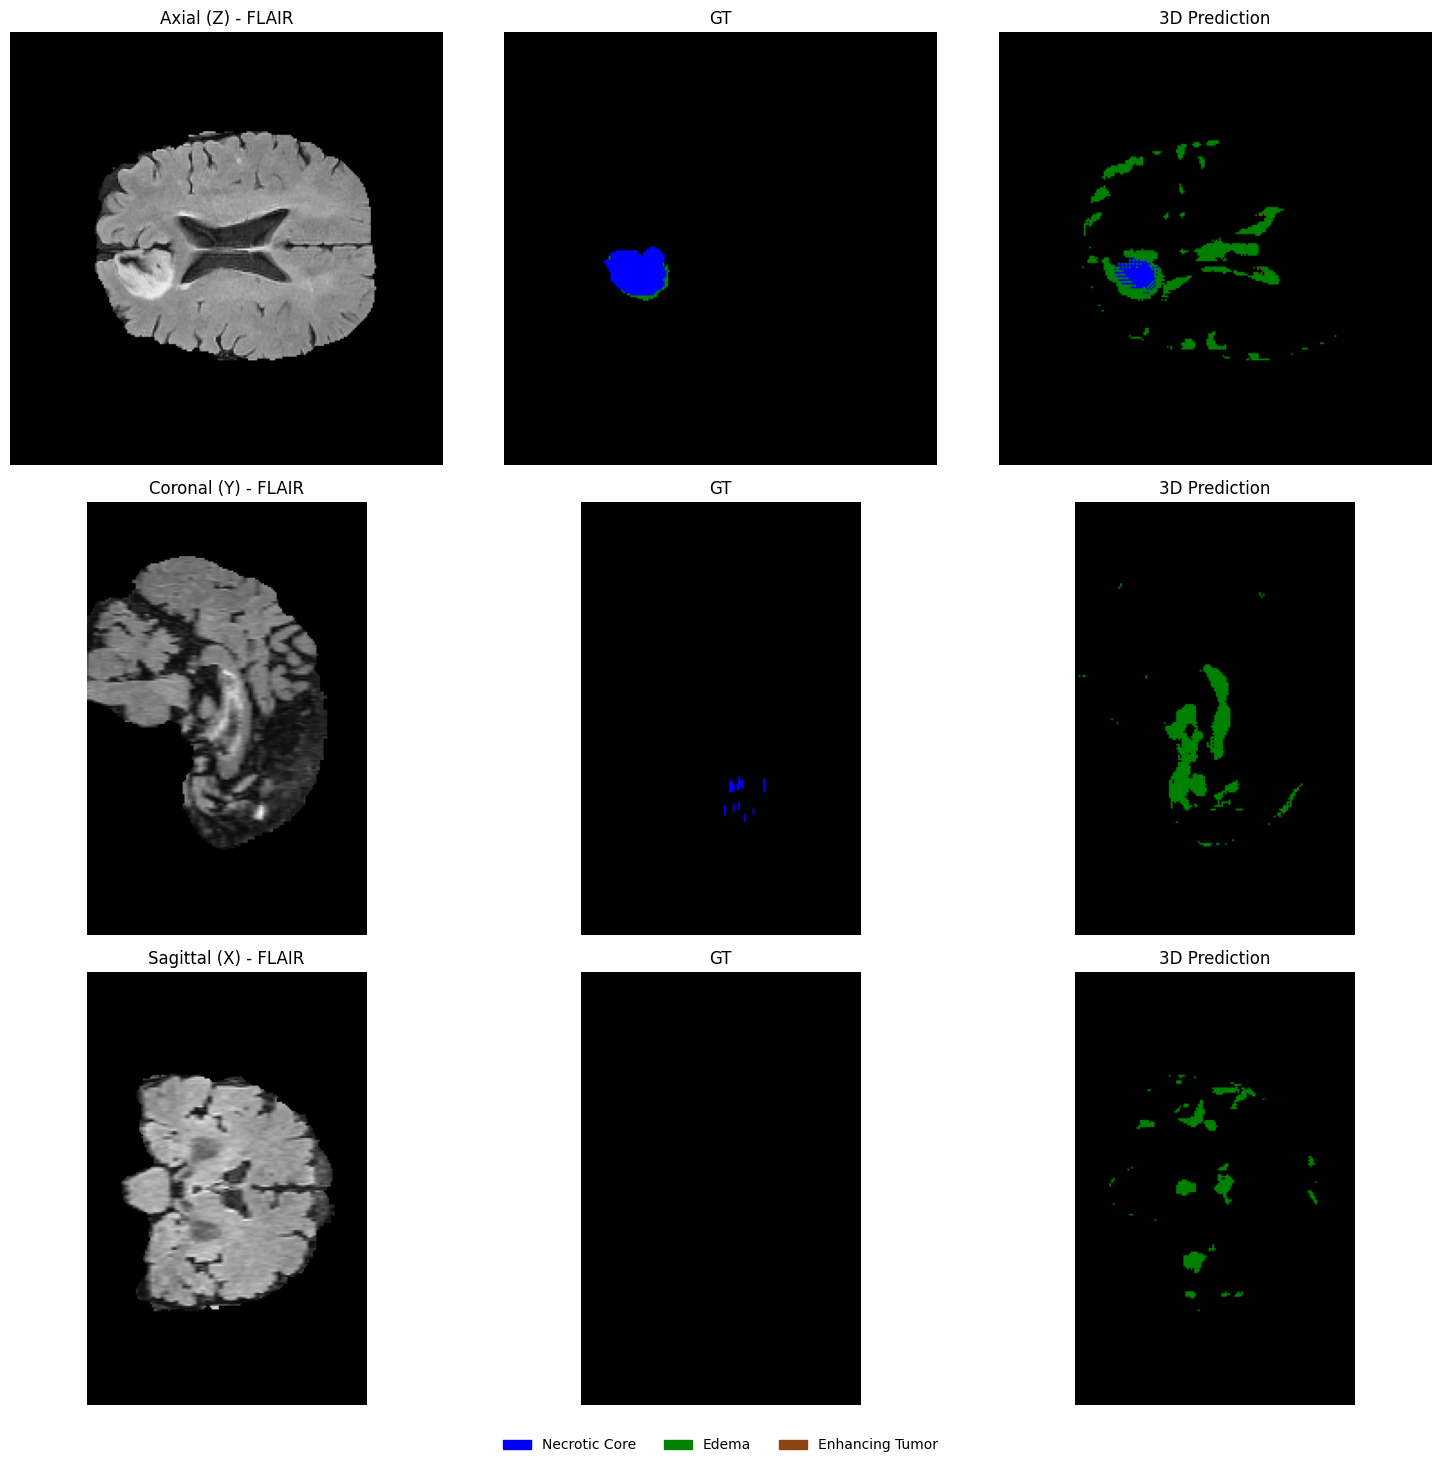

In [53]:
plot_orthogonal_views(flair, seg_gt, pred_volume, best_z)

In [54]:
def plot_3d_segmentation_overlays(flair, gt, pred, selected_slices, patient_id=""):
    """
    Plots a side-by-side comparison of GT and Prediction.
    flair: (H, W, D) -> (240, 240, 155)
    gt & pred: (D, H, W) -> (155, 240, 240)
    """
    # 0. Sync flair dimension to match gt and pred (D, H, W)
    flair = np.transpose(flair, (2, 0, 1))

    # 1. Define the EDA-consistent colors (Labels 1, 2, 3)
    legend_patches = [
        mpatches.Patch(color="blue", label="Necrotic Core"),
        mpatches.Patch(color="green", label="Peritumoral Edema"),
        mpatches.Patch(color="saddlebrown", label="Enhancing Tumor"),
    ]
    overlay_cmap = ListedColormap(["blue", "green", "saddlebrown"])

    print(f"--- Clinical Overlays: Patient {patient_id} ---")

    for z in selected_slices:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Consistent setup for both Ground Truth and Prediction
        data_to_plot = [gt, pred]
        titles = ["Ground Truth Overlay", "3D Prediction Overlay"]

        for ax, volume, title in zip(axes, data_to_plot, titles):
            # --- Step 1: Plot the Grayscale MRI Base ---
            # Using index [z, :, :] because flair is now (D, H, W)
            ax.imshow(flair[z, :, :], cmap="gray")

            # --- Step 2: Create a Masked Volume ---
            # Masking 0s ensures the background remains grayscale FLAIR
            slice_data = volume[z, :, :]
            masked_data = np.ma.masked_where(slice_data == 0, slice_data)

            # --- Step 3: Overlay with Alpha ---
            # vmin=1, vmax=3 correctly maps (1: blue, 2: green, 3: saddlebrown)
            ax.imshow(masked_data, cmap=overlay_cmap, alpha=0.4, vmin=1, vmax=3)

            ax.set_title(f"{title} (Slice {z})")
            ax.axis("off")

        # --- Step 4: Unified Legend ---
        fig.legend(
            handles=legend_patches,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            fontsize=10,
            frameon=False
        )

        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()

--- Clinical Overlays: Patient BraTS19_TCIA10_266_1 ---


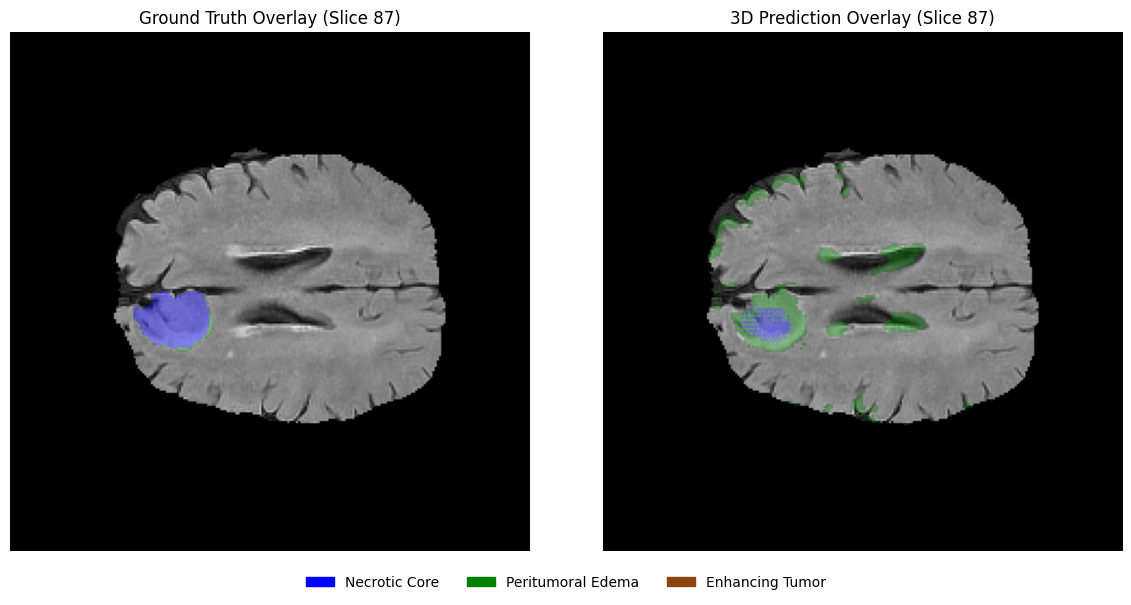

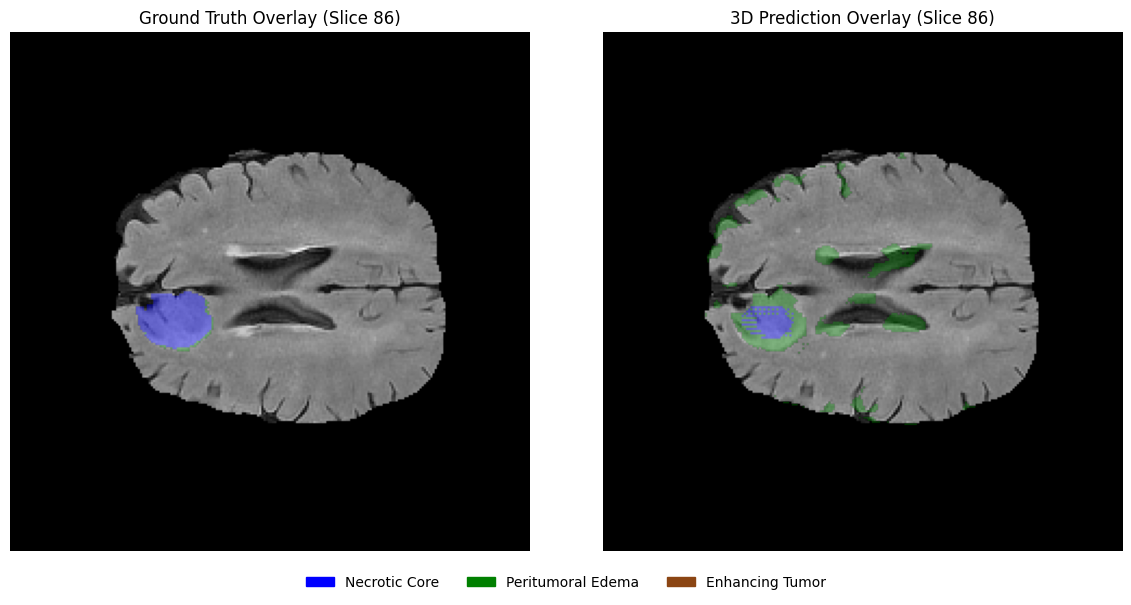

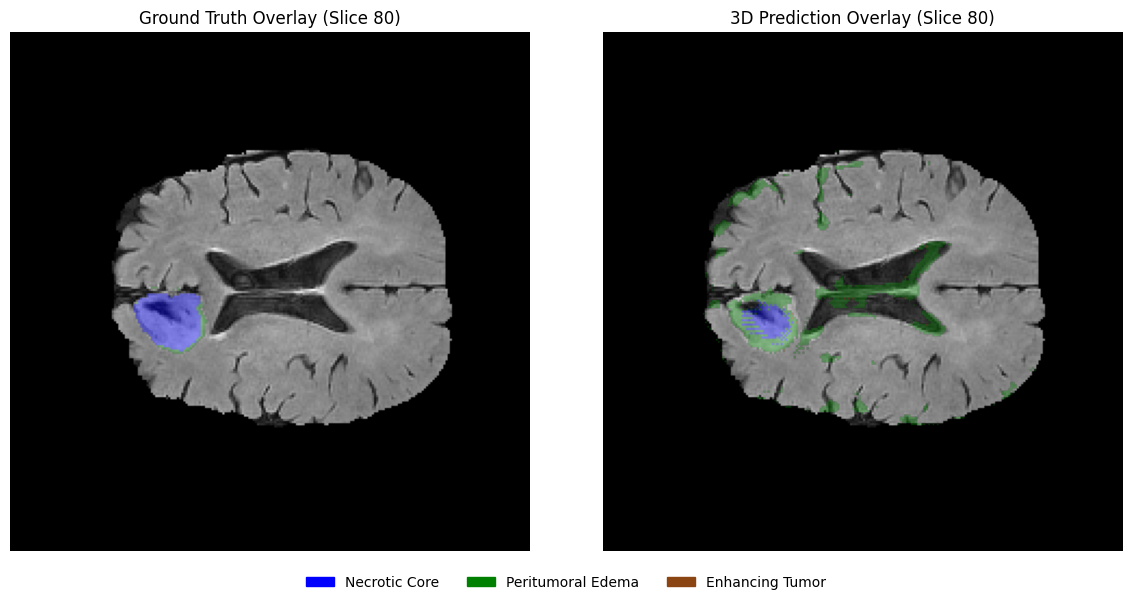

In [55]:
plot_3d_segmentation_overlays(
    flair=flair,
    gt=seg_gt,
    pred=pred_volume,
    selected_slices=selected_slices,
    patient_id=os.path.basename(viz_patient_dir)
)

# 5️⃣ Challenges & Limitations

While this tutorial demonstrates the core workflow for brain tumor segmentation using U-Net architectures, several practical limitations should be considered when interpreting the results.



## 5.1 Limited Dataset Size
To ensure that the tutorial can be executed on modest computational resources such as the free tier of Google Colab, we trained the models on only a small subset of the BraTS 2019 dataset. As a result, the models are not expected to achieve competitive segmentation performance. In research settings, models are typically trained on the full dataset and often with additional data augmentation strategies.

## 5.2 Transitioning from Notebooks to HPC
While Google Colab is excellent for interactive learning and EDA, production-level medical imaging research typically happens on High-Performance Computing (HPC) clusters.

**Advice:** To scale this work, you must transition from .ipynb to modular .py scripts. This allows for headless execution, easier version control with Git, and submission via job schedulers like SLURM.

**Access to Compute:** A common bottleneck—especially for learners in resource-constrained settings—is access to high-end GPUs. Practical pathways to overcome this include academic collaborations, as well as participation in mentorship or research programs. For example, initiatives such as the RISE-MICCAI mentorship program provide valuable exposure to real-world research practices and mentorship, and may also facilitate access to computational resources through collaborations with institutions including MBZUAI. Additionally, compute grants (e.g., NVIDIA Academic Hardware Grant or Google Cloud research credits) offer another viable route to obtaining the necessary infrastructure.

## 5.3 Robust Checkpointing & Reproducibility
In this tutorial, we prioritize a clear training flow. However, a professional research pipeline requires a more robust approach to state management:


*   **Resume Checkpoints:** Beyond saving model weights, it is standard practice to save the entire state_dict (including optimizer, learning rate scheduler, and current epoch) at the end of every epoch. This acts as an "insurance policy" against hardware preemption, power failures, or session timeouts, allowing you to resume training exactly where it was interrupted.
*   **Best-Model Selection & Inference:** We save the model that achieves the best validation metric. In a complete research workflow, these saved weights are then used to perform Inference on a completely held-out Test Set. This ensures that the final reported performance is truly generalizable and not biased by the model selection process on the validation data.


## 5.4 Model Capacity & Resolution Trade-offs
Medical features can be incredibly subtle. The architectures in this tutorial are optimized for Colab free tier’s resource constraints.

**Scaling Up:** If you have access to high-end computational resources, consider increasing the model width (initial channels), depth (number of levels), and input resolution.

## 5.5 Hyperparameter Sensitivity
Deep learning models in medical imaging are highly sensitive to hyperparameters, such as the Learning Rate (LR), Weight Decay, and Batch Size.

**Tuning:** The values provided in this tutorial are "reasonable defaults." For publication-grade results, you should employ a systematic search to find the optimal hyperparameters for your specific hardware and dataset.

## 5.6 Data Provenance & Standardization

Finding the primary official repository for historical challenge years can be difficult. According to the [Official BraTS Wiki on Synapse](https://www.synapse.org/Synapse:syn53708126/wiki/626320), several earlier instances—including BraTS 2019—are not currently hosted on the Synapse platform.



**Data Source for the Tutorial:** To ensure this tutorial remains reproducible and accessible, we have utilized a publicly available third-party mirror of the 2019 dataset.

**Research Recommendation:** For peer-reviewed publications, always use official data sources.


# Further Reading & References

## Further Reading


#### Automated Pipelines: The nnU-Net Framework
Most beginners spend weeks manually tuning settings like patch size, normalization, and data augmentation, but nnU-Net handles this automatically. It is a "self-configuring" framework that looks at your dataset and automatically chooses the best training strategy for you. Using nnU-Net helps you quickly achieve good results so you can focus on your research goals rather than low-level configuration.

#### Advanced Architectures: From CNNs to Transformers

While traditional CNNs are excellent at picking up local textures, Transformers allow the model to see the "big picture" by focusing on long-range relationships across the entire 3D volume. Modern architectures like UNETR or Swin UNETR combine the best of both worlds: using CNNs for fine details and Transformers to understand the global shape and location of the tumor.  Learning these hybrid models is the next step for achieving more precise segmentations in complex clinical cases.

#### Medical Foundation Models: MedSAM-2 and Promptable Segmentation

Instead of training a new model for every specific organ or tumor, Foundation Models like MedSAM-2 are pre-trained on millions of diverse medical images to act as a "universal" starting point. These models use Promptable Segmentation, allowing a user to simply click on a tumor or draw a rough box around it to generate a precise mask instantly without any additional training.  Mastering these models is the key to creating interactive clinical tools that can adapt to new types of scans with minimal effort.


## References

Menze, B. H., Jakab, A., Bauer, S., Kalpathy-Cramer, J., Farahani, K., Kirby, J., Burren, Y., Porz, N., Slotboom, J., Wiest, R., Lanczi, L., Gerstner, E., Weber, M.-A., Arbel, T., Avants, B. B., Ayache, N., Buendia, P., Collins, D. L., Cordier, N., . . . Durst, C. R. (2015). The multimodal brain tumor image segmentation benchmark (BRATS). IEEE Transactions on Medical Imaging, 34(10), 1993–2024. https://doi.org/10.1109/TMI.2014.2377694

Bakas, S., Akbari, H., Sotiras, A., Bilello, M., Rozycki, M., Kirby, J. S., Freymann, J. B., Farahani, K., & Davatzikos, C. (2017). Advancing The Cancer Genome Atlas glioma MRI collections with expert segmentation labels and radiomic features. Scientific Data, 4(1), Article 170117. https://doi.org/10.1038/sdata.2017.117

Bakas, S., Reyes, M., Jakab, A., Bauer, S., Rempfler, M., Crimi, A., Shinohara, R. T., Hamamci, A., Murphy, P. L., Gerstner, E., Albayrak, S., Bauer, S., Bernier, M., Bilello, M., Choudhury, S., Corso, J. J., Cuadra, M. B., Das, T., Degnan, G. J., . . . Menze, B. H. (2018). Identifying the best machine learning algorithms for brain tumor segmentation, progression assessment, and overall survival prediction in the BRATS challenge (arXiv:1811.02629). arXiv. https://doi.org/10.48550/arXiv.1811.02629

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. In N. Navab, J. Hornegger, W. M. Wells, & A. F. Frangi (Eds.), Medical image computing and computer-assisted intervention – MICCAI 2015 (Vol. 9351, pp. 234–241). Springer, Cham. https://doi.org/10.1007/978-3-319-24574-4_28

Çiçek, Ö., Abdulkadir, A., Lienkamp, S. S., Brox, T., & Ronneberger, O. (2016). 3D U-Net: Learning Dense Volumetric Segmentation from Sparse Annotation. In S. Ourselin, L. Joskowicz, M. Sabuncu, G. Unal, & W. Wells (Eds.), Medical Image Computing and Computer-Assisted Intervention – MICCAI 2016 (Vol. 9901, pp. 424–432). Springer, Cham. https://doi.org/10.1007/978-3-319-46723-8_49

Milletari, F., Navab, N., & Ahmadi, S.-A. (2016). V-Net: Fully convolutional neural networks for volumetric medical image segmentation. 2016 Fourth International Conference on 3D Vision (3DV), 565–571. https://doi.org/10.1109/3DV.2016.79

Isensee, F., Jaeger, P. F., Kohl, S. A. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: A self-configuring method for deep learning-based biomedical image segmentation. Nature Methods, 18(2), 203–211. https://doi.org/10.1038/s41592-020-01008-z